In [ ]:
!pip install -q --upgrade transformers datasets accelerate pynvml bitsandbytes torch-pruning

In [ ]:
# =============================================================================
# BERT Compression Benchmark on SST-2
#
# Variants:
# 1) BERT Base (Baseline)
# 2) Global Magnitude Pruning (unstructured sparsity baseline; dense kernels)
# 3) Structured FFN Channel Pruning (post-training, deployable dense shrink)
# 4) Attention Head Pruning (stable manual structural pruning)
# 5) 2:4 Semi-Structured Sparse BERT (real sparse backend if supported)
# 6) DistilBERT SST-2
# 7) BERT Base FP16
# 8) BERT Base INT8 (bitsandbytes)
# 9) BERT Base INT4 (bitsandbytes NF4)
# 10) DepGraph Structured Pruning (50%) + fine-tune
#
# Benchmark principles:
# - Accuracy over full validation set.
# - Model-only latency via CUDA events on pre-tokenized fixed-shape batches.
# - GPU energy via NVML total-energy counter when supported.
# - Warmup excluded from timing/energy.
# - Repeated measured passes for stabler latency/throughput.
# =============================================================================


import gc
import math
import time
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
)
import pynvml

warnings.filterwarnings("ignore")

# -----------------------------
# 1) Config
# -----------------------------
SEED = 42

MODEL_NAME = "textattack/bert-base-uncased-SST-2"
DISTIL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
DATASET_NAME = "stanfordnlp/sst2"

MAX_LENGTH = 128
BATCH_SIZE = 32
WARMUP_FRAC = 0.20
BENCHMARK_REPEATS = 5

# Pruning settings
MAG_L2_AMOUNT = 0.10
STRUCT_FFN_AMOUNT = 0.10
HEADS_TO_PRUNE_PER_LAYER = 1
SEMI_STRUCT_KEEP_N = 2
SEMI_STRUCT_GROUP_M = 4

# Calibration for structured FFN pruning
CALIB_LIMIT = 512
CALIB_BATCH_SIZE = 16

# Benchmark behavior
USE_FIXED_SHAPE_PADDING = True
ALLOW_TF32 = True
ENABLE_CUDNN_BENCHMARK = True

# -----------------------------
# 2) Reproducibility + device
# -----------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("Please switch runtime to GPU before running this benchmark.")

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = ENABLE_CUDNN_BENCHMARK
torch.backends.cuda.matmul.allow_tf32 = ALLOW_TF32
torch.backends.cudnn.allow_tf32 = ALLOW_TF32

device = torch.device("cuda")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))

# -----------------------------
# 3) Dataset + tokenizers
# -----------------------------
dataset = load_dataset(DATASET_NAME)

val_texts = list(dataset["validation"]["sentence"])
val_labels = torch.tensor(dataset["validation"]["label"], dtype=torch.long)
train_texts = list(dataset["train"]["sentence"])

print("Validation samples:", len(val_texts))
print("Train samples:", len(train_texts))

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer_distil = AutoTokenizer.from_pretrained(DISTIL_NAME)

def build_eval_batches(tokenizer, texts, labels, batch_size=32, max_length=128):
    enc = tokenizer(
        texts,
        padding="max_length" if USE_FIXED_SHAPE_PADDING else True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    batches = []
    n = labels.size(0)
    keys = list(enc.keys())

    for i in range(0, n, batch_size):
        batch = {k: enc[k][i:i + batch_size].contiguous() for k in keys}
        batch["labels"] = labels[i:i + batch_size].contiguous()
        batches.append(batch)

    return batches

val_batches_bert = build_eval_batches(
    tokenizer_bert, val_texts, val_labels, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)
val_batches_distil = build_eval_batches(
    tokenizer_distil, val_texts, val_labels, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

# -----------------------------
# 4) NVML helpers
# -----------------------------
pynvml.nvmlInit()
nvml_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def sync_cuda():
    torch.cuda.synchronize()

def get_model_device(model):
    try:
        return next(model.parameters()).device
    except StopIteration:
        for _, buf in model.named_buffers():
            return buf.device
        return torch.device("cuda:0")

def get_total_energy_j():
    try:
        return pynvml.nvmlDeviceGetTotalEnergyConsumption(nvml_handle) / 1000.0
    except Exception:
        return None

def get_power_watts():
    try:
        return pynvml.nvmlDeviceGetPowerUsage(nvml_handle) / 1000.0
    except Exception:
        return None

def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# -----------------------------
# 5) Utility helpers
# -----------------------------
def batch_inputs_only(batch):
    return {k: v for k, v in batch.items() if k != "labels"}

def move_batch_to_device(batch_inputs, target_device):
    return {k: v.to(target_device, non_blocking=True) for k, v in batch_inputs.items()}

def nan_result():
    return {
        "Accuracy (%)": np.nan,
        "Model-only Latency (ms/sample, post-warmup)": np.nan,
        "Model-only Time (s, post-warmup)": np.nan,
        "Throughput (samples/s, post-warmup)": np.nan,
        "Measured Energy (J, post-warmup)": np.nan,
        "Energy per Sample (J/sample, post-warmup)": np.nan,
        "Warmup Batches": np.nan,
        "Benchmark Repeats": np.nan,
    }

def compute_global_zero_fraction(model):
    total = 0
    zeros = 0
    for _, p in model.named_parameters():
        if not p.is_floating_point():
            continue
        if p.layout != torch.strided:
            continue
        x = p.detach()
        total += x.numel()
        zeros += (x == 0).sum().item()
    return (zeros / total) if total > 0 else np.nan

# -----------------------------
# 6) Accuracy + benchmarking
# -----------------------------
def accuracy_pass(model, eval_batches, preplaced_or_dispatched=False):
    model.eval()

    if preplaced_or_dispatched:
        model_device = get_model_device(model)
    else:
        model = model.to(device)
        model_device = device

    preds = []

    with torch.inference_mode():
        for batch in eval_batches:
            inputs = move_batch_to_device(batch_inputs_only(batch), model_device)
            logits = model(**inputs).logits
            pred = torch.argmax(logits, dim=1).detach().cpu()
            preds.append(pred)

    preds = torch.cat(preds)
    labels = torch.cat([b["labels"] for b in eval_batches], dim=0)
    acc = (preds == labels).float().mean().item() * 100.0
    return acc

def benchmark_pass(
    model,
    eval_batches,
    preplaced_or_dispatched=False,
    warmup_frac=0.20,
    repeats=5,
):
    model.eval()

    if preplaced_or_dispatched:
        model_device = get_model_device(model)
    else:
        model = model.to(device)
        model_device = device

    total_batches = len(eval_batches)
    warmup_batches = 0 if total_batches <= 1 else min(
        total_batches - 1, math.ceil(total_batches * warmup_frac)
    )

    device_batches = []
    for batch in eval_batches:
        device_batches.append(move_batch_to_device(batch_inputs_only(batch), model_device))

    measured_batches = device_batches[warmup_batches:]
    measured_samples_per_pass = sum(
        eval_batches[i]["labels"].size(0) for i in range(warmup_batches, total_batches)
    )

    if len(measured_batches) == 0 or measured_samples_per_pass == 0:
        return {
            "Model-only Latency (ms/sample, post-warmup)": np.nan,
            "Model-only Time (s, post-warmup)": np.nan,
            "Throughput (samples/s, post-warmup)": np.nan,
            "Measured Energy (J, post-warmup)": np.nan,
            "Energy per Sample (J/sample, post-warmup)": np.nan,
            "Warmup Batches": warmup_batches,
            "Benchmark Repeats": repeats,
        }

    # Warmup
    with torch.inference_mode():
        for batch in device_batches[:warmup_batches]:
            _ = model(**batch)
    sync_cuda()

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    using_total_energy = get_total_energy_j() is not None
    energy_start_j = None
    energy_end_j = None
    fallback_energy_j = 0.0

    total_model_time_ms = 0.0
    total_measured_samples = measured_samples_per_pass * repeats

    with torch.inference_mode():
        if using_total_energy:
            sync_cuda()
            energy_start_j = get_total_energy_j()

        for _ in range(repeats):
            for batch in measured_batches:
                if not using_total_energy:
                    sync_cuda()
                    p0 = get_power_watts()
                    wall_t0 = time.perf_counter()

                start_event.record()
                _ = model(**batch)
                end_event.record()
                sync_cuda()

                total_model_time_ms += start_event.elapsed_time(end_event)

                if not using_total_energy:
                    wall_t1 = time.perf_counter()
                    p1 = get_power_watts()
                    if p0 is not None and p1 is not None:
                        fallback_energy_j += ((p0 + p1) / 2.0) * (wall_t1 - wall_t0)

        if using_total_energy:
            sync_cuda()
            energy_end_j = get_total_energy_j()

    measured_model_time_s = total_model_time_ms / 1000.0
    avg_latency_ms = total_model_time_ms / total_measured_samples
    throughput_sps = total_measured_samples / measured_model_time_s

    if using_total_energy and energy_start_j is not None and energy_end_j is not None:
        measured_energy_j = max(0.0, energy_end_j - energy_start_j)
    else:
        measured_energy_j = fallback_energy_j

    energy_per_sample_j = (
        measured_energy_j / total_measured_samples if total_measured_samples > 0 else np.nan
    )

    return {
        "Model-only Latency (ms/sample, post-warmup)": avg_latency_ms,
        "Model-only Time (s, post-warmup)": measured_model_time_s,
        "Throughput (samples/s, post-warmup)": throughput_sps,
        "Measured Energy (J, post-warmup)": measured_energy_j,
        "Energy per Sample (J/sample, post-warmup)": energy_per_sample_j,
        "Warmup Batches": warmup_batches,
        "Benchmark Repeats": repeats,
    }

def evaluate_model(model, eval_batches, preplaced_or_dispatched=False):
    acc = accuracy_pass(
        model=model,
        eval_batches=eval_batches,
        preplaced_or_dispatched=preplaced_or_dispatched,
    )
    bench = benchmark_pass(
        model=model,
        eval_batches=eval_batches,
        preplaced_or_dispatched=preplaced_or_dispatched,
        warmup_frac=WARMUP_FRAC,
        repeats=BENCHMARK_REPEATS,
    )
    out = {"Accuracy (%)": acc}
    out.update(bench)
    return out

# -----------------------------
# 7) Global magnitude pruning
# -----------------------------
def magnitude_prune_l2_global(model, amount=0.10):
    model.eval()

    parameters_to_prune = []
    importance_scores = {}

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and "classifier" not in name:
            parameters_to_prune.append((module, "weight"))
            importance_scores[(module, "weight")] = module.weight.detach().pow(2).clone()

    if len(parameters_to_prune) == 0:
        return model

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        importance_scores=importance_scores,
        amount=amount,
    )

    for module, param_name in parameters_to_prune:
        prune.remove(module, param_name)

    return model

# -----------------------------
# 8) Structured FFN pruning
# -----------------------------
def collect_intermediate_activation_means(
    model,
    tokenizer,
    calib_texts,
    calib_limit=512,
    calib_batch_size=16,
):
    model = model.to(device).eval()

    activation_sums = {}
    activation_counts = {}
    hooks = []

    def make_hook(layer_idx):
        def hook(module, inputs, output):
            y = output.detach()
            if y.dim() == 3:
                stat = y.abs().mean(dim=(0, 1))
            elif y.dim() == 2:
                stat = y.abs().mean(dim=0)
            else:
                return

            if layer_idx not in activation_sums:
                activation_sums[layer_idx] = stat
                activation_counts[layer_idx] = 1
            else:
                activation_sums[layer_idx] += stat
                activation_counts[layer_idx] += 1
        return hook

    for layer_idx, layer in enumerate(model.bert.encoder.layer):
        hooks.append(layer.intermediate.dense.register_forward_hook(make_hook(layer_idx)))

    limit = min(len(calib_texts), calib_limit)

    with torch.inference_mode():
        for i in range(0, limit, calib_batch_size):
            batch = calib_texts[i:i + calib_batch_size]
            inputs = tokenizer(
                batch,
                padding="max_length" if USE_FIXED_SHAPE_PADDING else True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            _ = model(**inputs)

    for h in hooks:
        h.remove()

    act_means = {}
    for layer_idx in activation_sums:
        act_means[layer_idx] = activation_sums[layer_idx] / activation_counts[layer_idx]

    return act_means

def structured_ffn_prune_post_training(
    model,
    tokenizer,
    calib_texts,
    amount=0.10,
    calib_limit=512,
    calib_batch_size=16,
):
    model = model.to(device).eval()

    act_means = collect_intermediate_activation_means(
        model=model,
        tokenizer=tokenizer,
        calib_texts=calib_texts,
        calib_limit=calib_limit,
        calib_batch_size=calib_batch_size,
    )

    with torch.no_grad():
        for layer_idx, layer in enumerate(model.bert.encoder.layer):
            W1 = layer.intermediate.dense.weight.data
            b1 = layer.intermediate.dense.bias.data if layer.intermediate.dense.bias is not None else None
            W2 = layer.output.dense.weight.data
            b2 = layer.output.dense.bias.data if layer.output.dense.bias is not None else None

            num_channels = W1.size(0)
            prune_k = int(amount * num_channels)
            keep_k = num_channels - prune_k

            if prune_k <= 0 or keep_k <= 0:
                continue

            row_norm = torch.norm(W1, p=2, dim=1)
            col_norm = torch.norm(W2, p=2, dim=0)

            if layer_idx in act_means:
                act_score = act_means[layer_idx].to(W1.device, dtype=W1.dtype)
            else:
                act_score = torch.ones_like(row_norm)

            scores = act_score * (row_norm + col_norm)
            keep_idx = torch.topk(scores, k=keep_k, largest=True).indices.sort().values

            new_intermediate = nn.Linear(
                in_features=W1.size(1),
                out_features=keep_idx.numel(),
                bias=b1 is not None,
            ).to(W1.device, dtype=W1.dtype)
            new_intermediate.weight.data.copy_(W1[keep_idx, :].clone())
            if b1 is not None:
                new_intermediate.bias.data.copy_(b1[keep_idx].clone())

            new_output = nn.Linear(
                in_features=keep_idx.numel(),
                out_features=W2.size(0),
                bias=b2 is not None,
            ).to(W2.device, dtype=W2.dtype)
            new_output.weight.data.copy_(W2[:, keep_idx].clone())
            if b2 is not None:
                new_output.bias.data.copy_(b2.clone())

            layer.intermediate.dense = new_intermediate
            layer.output.dense = new_output

    return model

# -----------------------------
# 9) Attention head pruning
# Stable manual structural version
# -----------------------------
def prune_linear_layer_custom(layer, index, dim=0):
    index = index.to(layer.weight.device)
    W = layer.weight.data.index_select(dim, index).clone()

    if dim == 0:
        out_features = index.numel()
        in_features = layer.weight.size(1)
        new_layer = nn.Linear(
            in_features=in_features,
            out_features=out_features,
            bias=layer.bias is not None,
        ).to(layer.weight.device, dtype=layer.weight.dtype)
        new_layer.weight.data.copy_(W)
        if layer.bias is not None:
            new_layer.bias.data.copy_(layer.bias.data.index_select(0, index).clone())

    elif dim == 1:
        out_features = layer.weight.size(0)
        in_features = index.numel()
        new_layer = nn.Linear(
            in_features=in_features,
            out_features=out_features,
            bias=layer.bias is not None,
        ).to(layer.weight.device, dtype=layer.weight.dtype)
        new_layer.weight.data.copy_(W)
        if layer.bias is not None:
            new_layer.bias.data.copy_(layer.bias.data.clone())
    else:
        raise ValueError("dim must be 0 or 1")

    return new_layer

def score_attention_heads_by_weight_norm(attn_module):
    num_heads = attn_module.self.num_attention_heads
    head_size = attn_module.self.attention_head_size

    q_w = attn_module.self.query.weight.data
    k_w = attn_module.self.key.weight.data
    v_w = attn_module.self.value.weight.data
    o_w = attn_module.output.dense.weight.data

    head_scores = []
    for h in range(num_heads):
        s = h * head_size
        e = (h + 1) * head_size
        score = (
            q_w[s:e, :].pow(2).sum() +
            k_w[s:e, :].pow(2).sum() +
            v_w[s:e, :].pow(2).sum() +
            o_w[:, s:e].pow(2).sum()
        ).item()
        head_scores.append(score)

    return head_scores

def manually_prune_bert_attention_layer(attn_module, heads_to_prune):
    if len(heads_to_prune) == 0:
        return attn_module

    num_heads = attn_module.self.num_attention_heads
    head_size = attn_module.self.attention_head_size

    keep_heads = [h for h in range(num_heads) if h not in set(heads_to_prune)]
    if len(keep_heads) == 0:
        return attn_module

    keep_index = []
    for h in keep_heads:
        keep_index.extend(range(h * head_size, (h + 1) * head_size))
    keep_index = torch.tensor(
        keep_index,
        dtype=torch.long,
        device=attn_module.self.query.weight.device,
    )

    attn_module.self.query = prune_linear_layer_custom(attn_module.self.query, keep_index, dim=0)
    attn_module.self.key = prune_linear_layer_custom(attn_module.self.key, keep_index, dim=0)
    attn_module.self.value = prune_linear_layer_custom(attn_module.self.value, keep_index, dim=0)
    attn_module.output.dense = prune_linear_layer_custom(attn_module.output.dense, keep_index, dim=1)

    attn_module.self.num_attention_heads = len(keep_heads)
    attn_module.self.all_head_size = len(keep_heads) * head_size

    if hasattr(attn_module, "pruned_heads"):
        attn_module.pruned_heads = set(heads_to_prune)

    return attn_module

def attention_head_prune_stable(model, heads_to_prune_per_layer=1):
    model.eval()

    if not hasattr(model, "bert"):
        raise ValueError("This function expects a BERT-family model with model.bert.encoder.layer.")

    for layer in model.bert.encoder.layer:
        attn = layer.attention
        num_heads = attn.self.num_attention_heads
        prune_k = int(heads_to_prune_per_layer)

        if prune_k <= 0 or prune_k >= num_heads:
            continue

        head_scores = score_attention_heads_by_weight_norm(attn)
        prune_ids = np.argsort(head_scores)[:prune_k].tolist()
        layer.attention = manually_prune_bert_attention_layer(layer.attention, prune_ids)

    return model

#-----------------------------

def depgraph_structured_prune(
    model,
    amount=0.50,
    global_pruning=False,
    finetune=True,
    train_texts=None,
    train_labels=None,
    tokenizer=None,
    ft_epochs=3,
    ft_lr=2e-5,
    ft_batch_size=32,
):
    try:
        import torch_pruning as tp
    except ImportError:
        raise RuntimeError(
            "torch-pruning not installed. "
            "Add `torch-pruning` to your pip install cell and re-run."
        )

    model = model.to(device).eval()

    example_inputs = {
        "input_ids":      torch.zeros(1, MAX_LENGTH, dtype=torch.long,  device=device),
        "attention_mask": torch.ones(1,  MAX_LENGTH, dtype=torch.long,  device=device),
        "token_type_ids": torch.zeros(1, MAX_LENGTH, dtype=torch.long,  device=device),
    }

    ignored_layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Embedding, nn.LayerNorm)):
            ignored_layers.append(module)
        if isinstance(module, nn.Linear) and "classifier" in name:
            ignored_layers.append(module)

    imp = tp.importance.MagnitudeImportance(p=2, group_reduction="mean")

    pruner = tp.pruner.MagnitudePruner(
        model=model,
        example_inputs=example_inputs,
        importance=imp,
        pruning_ratio=amount,
        ignored_layers=ignored_layers,
        global_pruning=global_pruning,
        isomorphic=False,
    )

    pruner.step()

    # Patch attention head counts to stay consistent with new projection dims.
    if hasattr(model, "bert"):
        for layer in model.bert.encoder.layer:
            attn_self = layer.attention.self
            q_out = attn_self.query.out_features
            head_size = attn_self.attention_head_size
            new_num_heads = max(1, q_out // head_size)
            attn_self.num_attention_heads = new_num_heads
            attn_self.all_head_size = new_num_heads * head_size

    # Fine-tuning recovery pass.
    if finetune:
        if train_texts is None or train_labels is None or tokenizer is None:
            print("[DepGraph] Skipping fine-tune: train_texts, train_labels, or tokenizer not provided.")
        else:
            from torch.optim import AdamW
            from torch.utils.data import DataLoader, TensorDataset

            print("[DepGraph] Starting fine-tuning recovery...")
            model.train()

            enc = tokenizer(
                train_texts,
                padding="max_length",
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            labels_t = torch.tensor(train_labels, dtype=torch.long)

            # token_type_ids may not exist for all tokenizers (e.g. DistilBERT).
            token_type_ids = enc.get(
                "token_type_ids",
                torch.zeros_like(enc["input_ids"]),
            )

            ds = TensorDataset(
                enc["input_ids"],
                enc["attention_mask"],
                token_type_ids,
                labels_t,
            )
            loader = DataLoader(ds, batch_size=ft_batch_size, shuffle=True)
            optimizer = AdamW(model.parameters(), lr=ft_lr, weight_decay=0.01)

            for epoch in range(ft_epochs):
                total_loss = 0.0
                for ids, mask, ttype, lbl in loader:
                    optimizer.zero_grad()
                    out = model(
                        input_ids=ids.to(device),
                        attention_mask=mask.to(device),
                        token_type_ids=ttype.to(device),
                        labels=lbl.to(device),
                    )
                    out.loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    total_loss += out.loss.item()

                print(
                    f"  [DepGraph FT] Epoch {epoch + 1}/{ft_epochs} "
                    f"| Loss: {total_loss / len(loader):.4f}"
                )

            model.eval()
            print("[DepGraph] Fine-tuning complete.")

    return model

# -----------------------------
# 10) 2:4 semi-structured sparse BERT
# -----------------------------
def top2of4_mask(weight, keep_n=2, group_m=4):
    out_features, in_features = weight.shape
    if in_features < group_m:
        return weight

    pad = (group_m - (in_features % group_m)) % group_m
    if pad > 0:
        Wp = torch.cat(
            [weight, torch.zeros(out_features, pad, device=weight.device, dtype=weight.dtype)],
            dim=1,
        )
    else:
        Wp = weight

    Wg = Wp.view(out_features, -1, group_m)
    abs_Wg = Wg.abs()

    top_idx = torch.topk(abs_Wg, k=keep_n, dim=2, largest=True).indices
    mask = torch.zeros_like(Wg)
    mask.scatter_(2, top_idx, 1.0)

    pruned = (Wg * mask).view(out_features, -1)[:, :in_features]
    return pruned.contiguous()

def semi_structured_2to4_sparse_bert(
    model,
    keep_n=2,
    group_m=4,
    include_attention=True,
    include_ffn=True,
):
    try:
        from torch.sparse import to_sparse_semi_structured
    except Exception as e:
        raise RuntimeError("torch.sparse.to_sparse_semi_structured is not available in this runtime.") from e

    model = model.to(device).eval().half()
    converted = 0

    target_names = []
    if include_attention:
        target_names += [
            "attention.self.query",
            "attention.self.key",
            "attention.self.value",
            "attention.output.dense",
        ]
    if include_ffn:
        target_names += [
            "intermediate.dense",
            "output.dense",
        ]

    with torch.no_grad():
        for name, module in model.named_modules():
            if not isinstance(module, nn.Linear):
                continue
            if "classifier" in name:
                continue
            if not any(x in name for x in target_names):
                continue

            W = module.weight.data
            if W.device.type != "cuda":
                continue
            if W.dtype not in (torch.float16, torch.bfloat16):
                continue
            if W.size(1) < group_m:
                continue

            masked = top2of4_mask(W, keep_n=keep_n, group_m=group_m)

            try:
                sparse_w = to_sparse_semi_structured(masked)
                module.weight = nn.Parameter(sparse_w, requires_grad=False)
                converted += 1
            except Exception:
                continue

    if converted == 0:
        raise RuntimeError("No linear layers were converted to SparseSemiStructuredTensor.")
    return model

# -----------------------------
# 11) Runners
# -----------------------------
results = []

def add_result(results_list, res, name, notes="", dense_zero_frac=np.nan):
    row = dict(res)
    row["Model Variant"] = name
    row["Dense Zero Fraction"] = dense_zero_frac
    row["Notes"] = notes
    results_list.append(row)

def safe_run_variant(
    name,
    build_model_fn,
    eval_batches,
    notes="",
    preplaced_or_dispatched=False,
):
    cleanup()
    model = None
    try:
        model = build_model_fn()
        res = evaluate_model(
            model=model,
            eval_batches=eval_batches,
            preplaced_or_dispatched=preplaced_or_dispatched,
        )

        dense_zero_frac = np.nan
        try:
            dense_zero_frac = compute_global_zero_fraction(model)
        except Exception:
            dense_zero_frac = np.nan

        add_result(
            results_list=results,
            res=res,
            name=name,
            notes=notes,
            dense_zero_frac=dense_zero_frac,
        )
    except Exception as e:
        failed = nan_result()
        failed["Failure"] = repr(e)
        add_result(
            results_list=results,
            res=failed,
            name=name,
            notes=notes,
            dense_zero_frac=np.nan,
        )
        print(f"[WARN] {name} failed: {repr(e)}")
    finally:
        try:
            del model
        except Exception:
            pass
        cleanup()

# -----------------------------
# 12) Run variants
# -----------------------------
try:
    # 12.1 Baseline
    safe_run_variant(
        name="BERT Base (Baseline)",
        build_model_fn=lambda: AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
        eval_batches=val_batches_bert,
        notes="Dense FP32 baseline.",
        preplaced_or_dispatched=False,
    )

    # 12.2 Global magnitude pruning
    safe_run_variant(
        name=f"Global Magnitude Pruning ({int(MAG_L2_AMOUNT*100)}%)",
        build_model_fn=lambda: magnitude_prune_l2_global(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            amount=MAG_L2_AMOUNT,
        ),
        eval_batches=val_batches_bert,
        notes="Unstructured zeroing; dense kernels usually remain dense at runtime.",
        preplaced_or_dispatched=False,
    )

    # 12.3 Structured FFN pruning
    safe_run_variant(
        name=f"Structured FFN Channel Pruning ({int(STRUCT_FFN_AMOUNT*100)}%)",
        build_model_fn=lambda: structured_ffn_prune_post_training(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            tokenizer_bert,
            train_texts,
            amount=STRUCT_FFN_AMOUNT,
            calib_limit=CALIB_LIMIT,
            calib_batch_size=CALIB_BATCH_SIZE,
        ),
        eval_batches=val_batches_bert,
        notes="Physically shrinks FFN width for deployable dense inference.",
        preplaced_or_dispatched=False,
    )

    # 12.4 Attention head pruning
    safe_run_variant(
        name=f"Attention Head Pruning ({HEADS_TO_PRUNE_PER_LAYER} head/layer)",
        build_model_fn=lambda: attention_head_prune_stable(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            heads_to_prune_per_layer=HEADS_TO_PRUNE_PER_LAYER,
        ),
        eval_batches=val_batches_bert,
        notes="Manual structural pruning of Q/K/V/O projections.",
        preplaced_or_dispatched=False,
    )

    # 12.4b DepGraph Structured Pruning @ 50% + fine-tune
    safe_run_variant(
        name="DepGraph Structured Pruning (50%) + FT",
        build_model_fn=lambda: depgraph_structured_prune(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            amount=0.50,
            global_pruning=False,
            finetune=True,
            train_texts=train_texts,
            train_labels=dataset["train"]["label"],
            tokenizer=tokenizer_bert,
            ft_epochs=3,
            ft_lr=2e-5,
            ft_batch_size=32,
        ),
        eval_batches=val_batches_bert,
        notes=(
            "DepGraph 50% channel removal + 3-epoch fine-tune recovery. "
            "L2 magnitude importance; coupled Q/K/V/O + FFN groups."
        ),
        preplaced_or_dispatched=False,
    )

    # 12.5 2:4 semi-structured sparse BERT
    safe_run_variant(
        name=f"2:4 Semi-Structured Sparse BERT ({SEMI_STRUCT_KEEP_N}:{SEMI_STRUCT_GROUP_M})",
        build_model_fn=lambda: semi_structured_2to4_sparse_bert(
            AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME,
                torch_dtype=torch.float16,
            ),
            keep_n=SEMI_STRUCT_KEEP_N,
            group_m=SEMI_STRUCT_GROUP_M,
            include_attention=True,
            include_ffn=True,
        ),
        eval_batches=val_batches_bert,
        notes="Real sparse backend path when supported by runtime and GPU.",
        preplaced_or_dispatched=True,
    )

    # 12.6 DistilBERT
    safe_run_variant(
        name="DistilBERT SST-2",
        build_model_fn=lambda: AutoModelForSequenceClassification.from_pretrained(DISTIL_NAME),
        eval_batches=val_batches_distil,
        notes="Smaller dense model baseline.",
        preplaced_or_dispatched=False,
    )

    # 12.7 FP16
    safe_run_variant(
        name="BERT Base FP16",
        build_model_fn=lambda: AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            torch_dtype=torch.float16,
        ),
        eval_batches=val_batches_bert,
        notes="Dense half-precision baseline.",
        preplaced_or_dispatched=False,
    )

    # 12.8 INT8 bitsandbytes
    def build_int8_model():
        quant_config_8 = BitsAndBytesConfig(
            load_in_8bit=True,
            llm_int8_skip_modules=["classifier"],
        )
        return AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            quantization_config=quant_config_8,
            device_map="auto",
        )

    safe_run_variant(
        name="BERT Base INT8 Quantized",
        build_model_fn=build_int8_model,
        eval_batches=val_batches_bert,
        notes="bitsandbytes INT8 with classifier kept dense.",
        preplaced_or_dispatched=True,
    )

    # 12.9 INT4 bitsandbytes NF4
    def build_int4_model():
        quant_config_4 = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        return AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            quantization_config=quant_config_4,
            device_map="auto",
            torch_dtype=torch.float16,
        )

    safe_run_variant(
        name="BERT Base INT4 Quantized",
        build_model_fn=build_int4_model,
        eval_batches=val_batches_bert,
        notes="bitsandbytes 4-bit NF4 path.",
        preplaced_or_dispatched=True,
    )

    # -----------------------------
    # 13) Output
    # -----------------------------
    df = pd.DataFrame(results)

    preferred_cols = [
        "Model Variant",
        "Accuracy (%)",
        "Model-only Latency (ms/sample, post-warmup)",
        "Model-only Time (s, post-warmup)",
        "Throughput (samples/s, post-warmup)",
        "Measured Energy (J, post-warmup)",
        "Energy per Sample (J/sample, post-warmup)",
        "Dense Zero Fraction",
        "Warmup Batches",
        "Benchmark Repeats",
        "Notes",
    ]

    extra_cols = [c for c in df.columns if c not in preferred_cols]
    df = df[preferred_cols + extra_cols]

    df = df.sort_values(
        by=["Accuracy (%)", "Throughput (samples/s, post-warmup)"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)

    print("\nFinal comparison table:")
    print(df.round(4).to_string(index=False))

finally:
    try:
        pynvml.nvmlShutdown()
    except Exception:
        pass

Using device: cuda
GPU: NVIDIA L4
Validation samples: 872
Train samples: 67349


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Final comparison table:
                         Model Variant  Accuracy (%)  Model-only Latency (ms/sample, post-warmup)  Model-only Time (s, post-warmup)  Throughput (samples/s, post-warmup)  Measured Energy (J, post-warmup)  Energy per Sample (J/sample, post-warmup)  Dense Zero Fraction  Warmup Batches  Benchmark Repeats                                                                                                             Notes
                        BERT Base FP16       92.4312                                       0.7014                            2.3846                            1425.8034                           172.614                                     0.0508               0.0000               6                  5                                                                                    Dense half-precision baseline.
                  BERT Base (Baseline)       92.4312                                       1.2656                            4.3029            

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

data = [
    ("BERT Base FP16",             92.43, 0.70, 1425.8, 0.0508, "Quantization"),
    ("BERT Base (Baseline)",        92.43, 1.27,  790.2, 0.0911, "Baseline"),
    ("Global Magnitude Pruning 10%",92.43, 1.27,  789.4, 0.0932, "Unstructured"),
    ("Attention Head Pruning",      92.32, 1.28,  779.6, 0.0934, "Structured"),
    ("BERT Base INT8",              92.09, 3.09,  323.3, 0.2201, "Quantization"),
    ("BERT Base INT4 (NF4)",        91.97, 0.93, 1080.9, 0.0668, "Quantization"),
    ("DistilBERT SST-2",            91.06, 0.69, 1451.6, 0.0487, "Knowledge Distillation"),
    ("Structured FFN Pruning 10%",  89.91, 1.32,  756.4, 0.0953, "Structured"),
    ("DepGraph 50% + FT",           88.07, 0.70, 1436.4, 0.0508, "Structured"),
    ("2:4 Semi-Structured Sparse",  84.06, 3.35,  298.7, 0.1878, "Semi-Structured"),
]

# Sort by accuracy desc
data = sorted(data, key=lambda x: -x[1])

TYPE_COLORS = {
    "Baseline":        "#888780",
    "Quantization":    "#185FA5",
    "Unstructured":    "#993C1D",
    "Structured":      "#0F6E56",
    "Semi-Structured": "#854F0B",
    "Knowledge Distillation": "#534AB7",
}

def acc_color(a):
    if a >= 92:   return "#3B6D11", "#EAF3DE"
    if a >= 89:   return "#0F6E56", "#E1F5EE"
    if a >= 84:   return "#854F0B", "#FAEEDA"
    return              "#A32D2D", "#FCEBEB"

BG       = "#FFFFFF"
BG2      = "#F7F6F2"
BORDER   = "#E0DED6"
TEXT_PRI = "#1A1A1A"
TEXT_SEC = "#6B6A65"
HEAD_BG  = "#F1EFE8"

fig_w, fig_h = 13, 7.8
fig = plt.figure(figsize=(fig_w, fig_h), facecolor=BG)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_facecolor(BG)
ax.set_xlim(0, fig_w)
ax.set_ylim(0, fig_h)
ax.axis("off")

# Outer border
outer = FancyBboxPatch((0.18, 0.18), fig_w-0.36, fig_h-0.36,
                        boxstyle="round,pad=0.08", linewidth=1,
                        edgecolor=BORDER, facecolor=BG)
ax.add_patch(outer)

# Title
ax.text(fig_w/2, fig_h - 0.38, "BERT Compression Benchmark — SST-2",
        ha="center", va="center", fontsize=14, fontweight="bold",
        color=TEXT_PRI, fontfamily="DejaVu Sans")
ax.text(fig_w/2, fig_h - 0.68, "Evaluated on full validation set · L4 GPU · batch 32 · seq 128",
        ha="center", va="center", fontsize=9, color=TEXT_SEC)

# Column layout  [x_start, width, label, align]
SHIFT_X = 0.20

cols = [
    (0.50 + SHIFT_X, 2.60, "Model variant",         "left"),
    (3.05 + SHIFT_X, 1.00, "Accuracy",              "center"),
    (4.18 + SHIFT_X, 1.75, "Latency (ms/sample)",   "center"),
    (6.05 + SHIFT_X, 2.00, "Throughput (sample/s)",   "center"),
    (8.18 + SHIFT_X, 1.90, "Energy/sample (J)",     "center"),
    (10.15 + SHIFT_X, 2.25, "Type",                 "center"),
]

HEADER_Y = fig_h - 1.02
ROW_H    = 0.52
N_ROWS   = len(data)
TABLE_TOP = HEADER_Y - 0.02
TABLE_BOT = TABLE_TOP - (N_ROWS + 1) * ROW_H

# Header background
hdr_rect = FancyBboxPatch((0.22, TABLE_TOP - ROW_H), fig_w - 0.44, ROW_H,
                           boxstyle="square,pad=0", linewidth=0,
                           facecolor=HEAD_BG)
ax.add_patch(hdr_rect)

# Header labels
for (cx, cw, label, align) in cols:
    if label == "Model variant":
        tx = cx + 0.05
    else:
        tx = cx + cw / 2 if align == "center" else cx
    ax.text(tx, TABLE_TOP - ROW_H / 2, label,
            ha=align, va="center", fontsize=8.5, fontweight="bold",
            color=TEXT_SEC, fontfamily="DejaVu Sans")

# Horizontal header line
ax.plot([0.22, fig_w - 0.22], [TABLE_TOP - ROW_H, TABLE_TOP - ROW_H],
        color=BORDER, linewidth=0.8)

# Max values for bars
max_lat = max(r[2] for r in data)
max_thr = max(r[3] for r in data)
max_eng = max(r[4] for r in data)

BAR_H   = 0.10
BAR_PAD = 0.18  # left padding inside bar cell

for i, (name, acc, lat, thr, eng, typ) in enumerate(data):
    y_top = TABLE_TOP - ROW_H * (i + 1)
    y_mid = y_top - ROW_H / 2

    # Alternating row bg
    if i % 2 == 1:
        row_rect = FancyBboxPatch((0.22, y_top - ROW_H), fig_w - 0.44, ROW_H,
                                   boxstyle="square,pad=0", linewidth=0,
                                   facecolor=BG2, zorder=0)
        ax.add_patch(row_rect)

    # Row separator
    ax.plot([0.22, fig_w - 0.22], [y_top - ROW_H, y_top - ROW_H],
            color=BORDER, linewidth=0.4, zorder=1)

    # --- Model name ---
    cx, cw, _, _ = cols[0]
    ax.text(cx + 0.05, y_mid, name,
            ha="left", va="center", fontsize=8.5, fontweight="500",
            color=TEXT_PRI, fontfamily="DejaVu Sans")

    # --- Accuracy badge ---
    cx, cw, _, _ = cols[1]
    tc, bc = acc_color(acc)
    badge_w, badge_h = 0.72, 0.24
    badge_x = cx + cw / 2 - badge_w / 2
    badge_rect = FancyBboxPatch((badge_x, y_mid - badge_h / 2), badge_w, badge_h,
                                 boxstyle="round,pad=0.03", linewidth=0,
                                 facecolor=bc, zorder=2)
    ax.add_patch(badge_rect)
    ax.text(cx + cw / 2, y_mid, f"{acc:.2f}%",
            ha="center", va="center", fontsize=8, fontweight="bold",
            color=tc, fontfamily="DejaVu Sans", zorder=3)

    def draw_bar(col_idx, val, max_val, color):
        cx2, cw2, _, _ = cols[col_idx]
        track_x = cx2 + BAR_PAD
        track_w = cw2 - BAR_PAD - 0.08
        track_y = y_mid - BAR_H / 2
        # Track
        ax.add_patch(FancyBboxPatch((track_x, track_y), track_w, BAR_H,
                                    boxstyle="round,pad=0.01", linewidth=0,
                                    facecolor="#E8E6E0", zorder=2))
        # Fill
        fill_w = max(0.02, (val / max_val) * track_w)
        ax.add_patch(FancyBboxPatch((track_x, track_y), fill_w, BAR_H,
                                    boxstyle="round,pad=0.01", linewidth=0,
                                    facecolor=color, alpha=0.85, zorder=3))
        # Value label (left-aligned, after bar)
        ax.text(cx2 + 0.06, y_mid - BAR_H - 0.005, f"{val:.2f}",
                ha="left", va="top", fontsize=7, color=TEXT_SEC,
                fontfamily="DejaVu Sans", zorder=4)

    # Latency — lower is better, invert bar
    draw_bar(2, lat, max_lat, "#185FA5")

    # Throughput
    draw_bar(3, thr, max_thr, "#0F6E56")

    # Energy
    draw_bar(4, eng, max_eng, "#854F0B")

    # --- Type pill ---
    cx, cw, _, _ = cols[5]
    tc2 = TYPE_COLORS.get(typ, "#888")
    ax.text(cx + cw / 2, y_mid, typ,
            ha="center", va="center", fontsize=7.5,
            color=tc2, fontfamily="DejaVu Sans", fontweight="bold")

# Outer table border lines
ax.plot([0.22, 0.22], [TABLE_TOP, TABLE_TOP - ROW_H * (N_ROWS + 1)],
        color=BORDER, linewidth=0.8)
ax.plot([fig_w - 0.22, fig_w - 0.22], [TABLE_TOP, TABLE_TOP - ROW_H * (N_ROWS + 1)],
        color=BORDER, linewidth=0.8)
ax.plot([0.22, fig_w - 0.22], [TABLE_TOP, TABLE_TOP],
        color=BORDER, linewidth=0.8)
ax.plot([0.22, fig_w - 0.22],
        [TABLE_TOP - ROW_H * (N_ROWS + 1), TABLE_TOP - ROW_H * (N_ROWS + 1)],
        color=BORDER, linewidth=0.8)

# Legend
legend_y = TABLE_BOT - 0.26
legend_items = [
    ("≥92% — best",    "#3B6D11", "#EAF3DE"),
    ("89–<92% — good", "#0F6E56", "#E1F5EE"),
    ("84–<89% — fair", "#854F0B", "#FAEEDA"),
    ("<84% — poor",    "#A32D2D", "#FCEBEB"),
]

lx = 0.28
ax.text(lx, legend_y, "Accuracy:", ha="left", va="center",
        fontsize=7.5, color=TEXT_SEC)
lx += 0.75
for label, tc, bc in legend_items:
    bw, bh = 1.05, 0.22
    ax.add_patch(FancyBboxPatch((lx, legend_y - bh/2), bw, bh,
                                 boxstyle="round,pad=0.03",
                                 facecolor=bc, linewidth=0, zorder=2))
    ax.text(lx + bw/2, legend_y, label,
            ha="center", va="center", fontsize=7, color=tc,
            fontfamily="DejaVu Sans", fontweight="bold", zorder=3)
    lx += bw + 0.12

# Type legend
lx2 = 0.28
type_legend_y = legend_y - 0.30
ax.text(lx2, type_legend_y, "Type:", ha="left", va="center",
        fontsize=7.5, color=TEXT_SEC)
lx2 += 0.75
for typ_name, col in TYPE_COLORS.items():
    dot = plt.Circle((lx2 + 0.07, type_legend_y), 0.055, color=col, zorder=2)
    ax.add_patch(dot)
    ax.text(lx2 + 0.18, type_legend_y, typ_name,
            ha="left", va="center", fontsize=7.5, color=TEXT_PRI,
            fontfamily="DejaVu Sans")
    lx2 += len(typ_name) * 0.09 + 0.40

out = "bert_benchmark_l4gpu.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor=BG, pad_inches=0.1)
print("Saved to", out)

Saved to bert_benchmark_l4gpu.png


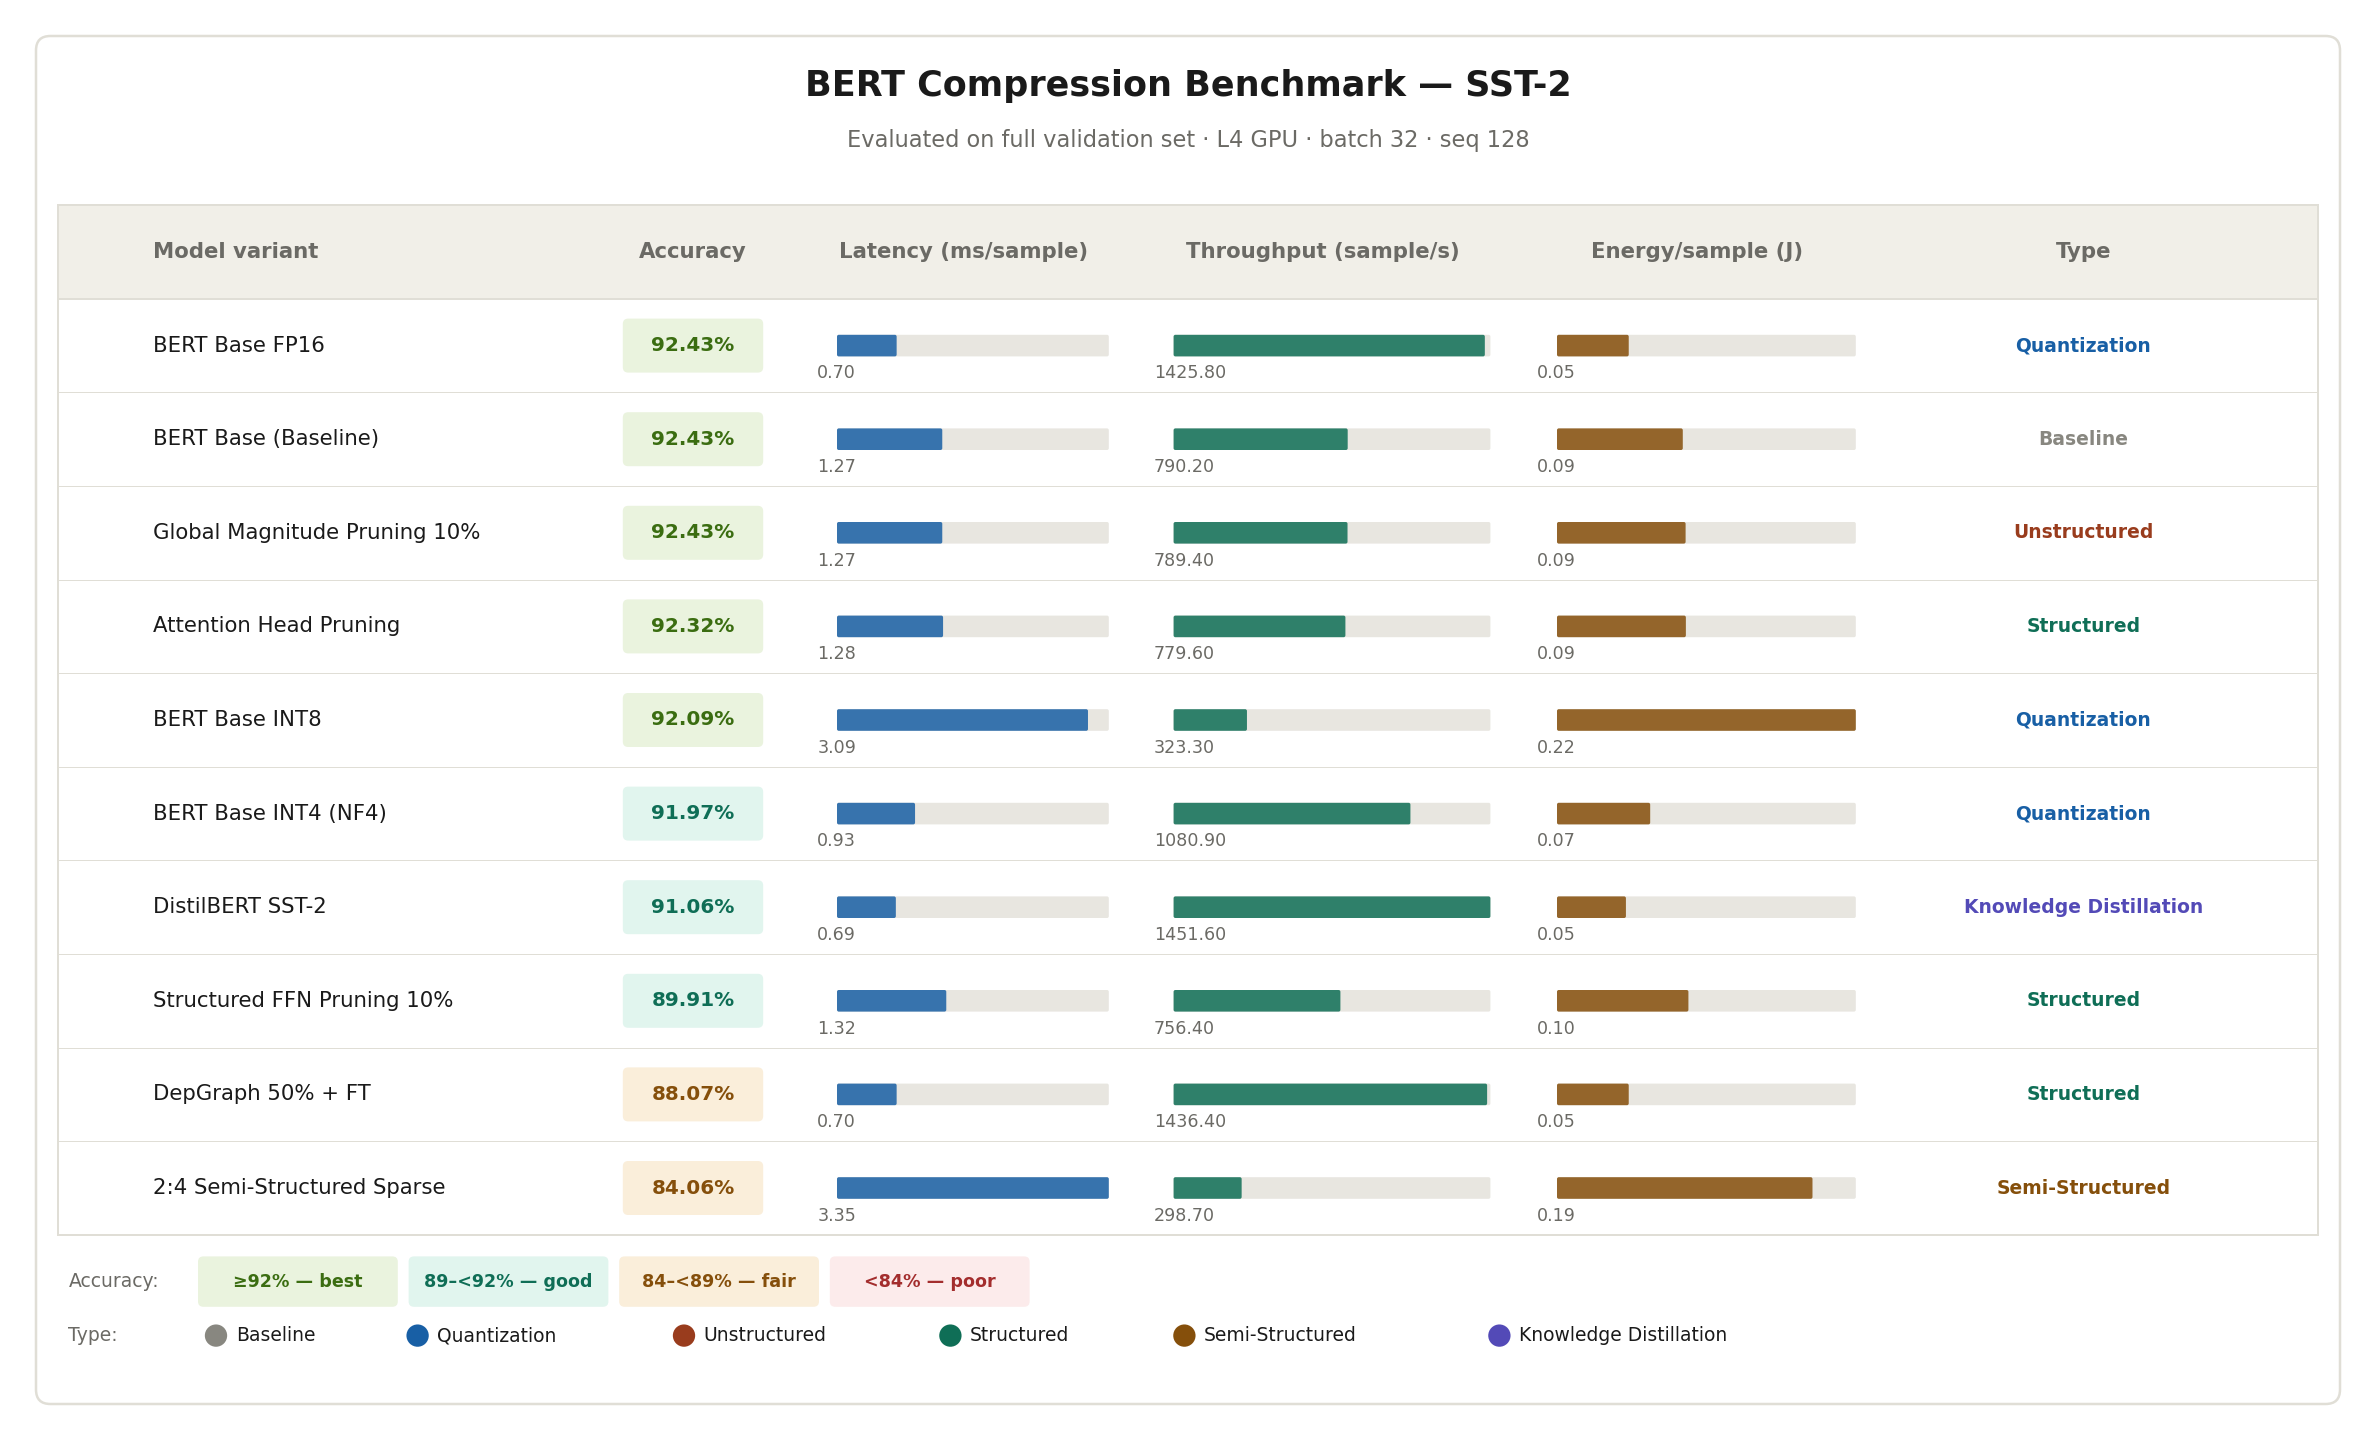

In [ ]:
from IPython.display import Image; display(Image("bert_benchmark_l4gpu.png"))

In [ ]:
# =============================================================================
# BERT Compression Benchmark on SST-2
#
# Variants:
# 1) BERT Base (Baseline)
# 2) Global Magnitude Pruning (unstructured sparsity baseline; dense kernels)
# 3) Structured FFN Channel Pruning (post-training, deployable dense shrink)
# 4) Attention Head Pruning (stable manual structural pruning)
# 5) 2:4 Semi-Structured Sparse BERT (real sparse backend if supported)
# 6) DistilBERT SST-2
# 7) BERT Base FP16
# 8) BERT Base INT8 (bitsandbytes)
# 9) BERT Base INT4 (bitsandbytes NF4)
# 10) DepGraph Structured Pruning (50%) + fine-tune
#
# Benchmark principles:
# - Accuracy over full validation set.
# - Model-only latency via CUDA events on pre-tokenized fixed-shape batches.
# - GPU energy via NVML total-energy counter when supported.
# - Warmup excluded from timing/energy.
# - Repeated measured passes for stabler latency/throughput.
# =============================================================================


import gc
import math
import time
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
)
import pynvml

warnings.filterwarnings("ignore")

# -----------------------------
# 1) Config
# -----------------------------
SEED = 42

MODEL_NAME = "textattack/bert-base-uncased-SST-2"
DISTIL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
DATASET_NAME = "stanfordnlp/sst2"

MAX_LENGTH = 128
BATCH_SIZE = 32
WARMUP_FRAC = 0.20
BENCHMARK_REPEATS = 5

# Pruning settings
MAG_L2_AMOUNT = 0.10
STRUCT_FFN_AMOUNT = 0.10
HEADS_TO_PRUNE_PER_LAYER = 1
SEMI_STRUCT_KEEP_N = 2
SEMI_STRUCT_GROUP_M = 4

# Calibration for structured FFN pruning
CALIB_LIMIT = 512
CALIB_BATCH_SIZE = 16

# Benchmark behavior
USE_FIXED_SHAPE_PADDING = True
ALLOW_TF32 = True
ENABLE_CUDNN_BENCHMARK = True

# -----------------------------
# 2) Reproducibility + device
# -----------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("Please switch runtime to GPU before running this benchmark.")

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = ENABLE_CUDNN_BENCHMARK
torch.backends.cuda.matmul.allow_tf32 = ALLOW_TF32
torch.backends.cudnn.allow_tf32 = ALLOW_TF32

device = torch.device("cuda")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))

# -----------------------------
# 3) Dataset + tokenizers
# -----------------------------
dataset = load_dataset(DATASET_NAME)

val_texts = list(dataset["validation"]["sentence"])
val_labels = torch.tensor(dataset["validation"]["label"], dtype=torch.long)
train_texts = list(dataset["train"]["sentence"])

print("Validation samples:", len(val_texts))
print("Train samples:", len(train_texts))

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer_distil = AutoTokenizer.from_pretrained(DISTIL_NAME)

def build_eval_batches(tokenizer, texts, labels, batch_size=32, max_length=128):
    enc = tokenizer(
        texts,
        padding="max_length" if USE_FIXED_SHAPE_PADDING else True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    batches = []
    n = labels.size(0)
    keys = list(enc.keys())

    for i in range(0, n, batch_size):
        batch = {k: enc[k][i:i + batch_size].contiguous() for k in keys}
        batch["labels"] = labels[i:i + batch_size].contiguous()
        batches.append(batch)

    return batches

val_batches_bert = build_eval_batches(
    tokenizer_bert, val_texts, val_labels, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)
val_batches_distil = build_eval_batches(
    tokenizer_distil, val_texts, val_labels, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

# -----------------------------
# 4) NVML helpers
# -----------------------------
pynvml.nvmlInit()
nvml_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def sync_cuda():
    torch.cuda.synchronize()

def get_model_device(model):
    try:
        return next(model.parameters()).device
    except StopIteration:
        for _, buf in model.named_buffers():
            return buf.device
        return torch.device("cuda:0")

def get_total_energy_j():
    try:
        return pynvml.nvmlDeviceGetTotalEnergyConsumption(nvml_handle) / 1000.0
    except Exception:
        return None

def get_power_watts():
    try:
        return pynvml.nvmlDeviceGetPowerUsage(nvml_handle) / 1000.0
    except Exception:
        return None

def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# -----------------------------
# 5) Utility helpers
# -----------------------------
def batch_inputs_only(batch):
    return {k: v for k, v in batch.items() if k != "labels"}

def move_batch_to_device(batch_inputs, target_device):
    return {k: v.to(target_device, non_blocking=True) for k, v in batch_inputs.items()}

def nan_result():
    return {
        "Accuracy (%)": np.nan,
        "Model-only Latency (ms/sample, post-warmup)": np.nan,
        "Model-only Time (s, post-warmup)": np.nan,
        "Throughput (samples/s, post-warmup)": np.nan,
        "Measured Energy (J, post-warmup)": np.nan,
        "Energy per Sample (J/sample, post-warmup)": np.nan,
        "Warmup Batches": np.nan,
        "Benchmark Repeats": np.nan,
    }

def compute_global_zero_fraction(model):
    total = 0
    zeros = 0
    for _, p in model.named_parameters():
        if not p.is_floating_point():
            continue
        if p.layout != torch.strided:
            continue
        x = p.detach()
        total += x.numel()
        zeros += (x == 0).sum().item()
    return (zeros / total) if total > 0 else np.nan

# -----------------------------
# 6) Accuracy + benchmarking
# -----------------------------
def accuracy_pass(model, eval_batches, preplaced_or_dispatched=False):
    model.eval()

    if preplaced_or_dispatched:
        model_device = get_model_device(model)
    else:
        model = model.to(device)
        model_device = device

    preds = []

    with torch.inference_mode():
        for batch in eval_batches:
            inputs = move_batch_to_device(batch_inputs_only(batch), model_device)
            logits = model(**inputs).logits
            pred = torch.argmax(logits, dim=1).detach().cpu()
            preds.append(pred)

    preds = torch.cat(preds)
    labels = torch.cat([b["labels"] for b in eval_batches], dim=0)
    acc = (preds == labels).float().mean().item() * 100.0
    return acc

def benchmark_pass(
    model,
    eval_batches,
    preplaced_or_dispatched=False,
    warmup_frac=0.20,
    repeats=5,
):
    model.eval()

    if preplaced_or_dispatched:
        model_device = get_model_device(model)
    else:
        model = model.to(device)
        model_device = device

    total_batches = len(eval_batches)
    warmup_batches = 0 if total_batches <= 1 else min(
        total_batches - 1, math.ceil(total_batches * warmup_frac)
    )

    device_batches = []
    for batch in eval_batches:
        device_batches.append(move_batch_to_device(batch_inputs_only(batch), model_device))

    measured_batches = device_batches[warmup_batches:]
    measured_samples_per_pass = sum(
        eval_batches[i]["labels"].size(0) for i in range(warmup_batches, total_batches)
    )

    if len(measured_batches) == 0 or measured_samples_per_pass == 0:
        return {
            "Model-only Latency (ms/sample, post-warmup)": np.nan,
            "Model-only Time (s, post-warmup)": np.nan,
            "Throughput (samples/s, post-warmup)": np.nan,
            "Measured Energy (J, post-warmup)": np.nan,
            "Energy per Sample (J/sample, post-warmup)": np.nan,
            "Warmup Batches": warmup_batches,
            "Benchmark Repeats": repeats,
        }

    # Warmup
    with torch.inference_mode():
        for batch in device_batches[:warmup_batches]:
            _ = model(**batch)
    sync_cuda()

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    using_total_energy = get_total_energy_j() is not None
    energy_start_j = None
    energy_end_j = None
    fallback_energy_j = 0.0

    total_model_time_ms = 0.0
    total_measured_samples = measured_samples_per_pass * repeats

    with torch.inference_mode():
        if using_total_energy:
            sync_cuda()
            energy_start_j = get_total_energy_j()

        for _ in range(repeats):
            for batch in measured_batches:
                if not using_total_energy:
                    sync_cuda()
                    p0 = get_power_watts()
                    wall_t0 = time.perf_counter()

                start_event.record()
                _ = model(**batch)
                end_event.record()
                sync_cuda()

                total_model_time_ms += start_event.elapsed_time(end_event)

                if not using_total_energy:
                    wall_t1 = time.perf_counter()
                    p1 = get_power_watts()
                    if p0 is not None and p1 is not None:
                        fallback_energy_j += ((p0 + p1) / 2.0) * (wall_t1 - wall_t0)

        if using_total_energy:
            sync_cuda()
            energy_end_j = get_total_energy_j()

    measured_model_time_s = total_model_time_ms / 1000.0
    avg_latency_ms = total_model_time_ms / total_measured_samples
    throughput_sps = total_measured_samples / measured_model_time_s

    if using_total_energy and energy_start_j is not None and energy_end_j is not None:
        measured_energy_j = max(0.0, energy_end_j - energy_start_j)
    else:
        measured_energy_j = fallback_energy_j

    energy_per_sample_j = (
        measured_energy_j / total_measured_samples if total_measured_samples > 0 else np.nan
    )

    return {
        "Model-only Latency (ms/sample, post-warmup)": avg_latency_ms,
        "Model-only Time (s, post-warmup)": measured_model_time_s,
        "Throughput (samples/s, post-warmup)": throughput_sps,
        "Measured Energy (J, post-warmup)": measured_energy_j,
        "Energy per Sample (J/sample, post-warmup)": energy_per_sample_j,
        "Warmup Batches": warmup_batches,
        "Benchmark Repeats": repeats,
    }

def evaluate_model(model, eval_batches, preplaced_or_dispatched=False):
    acc = accuracy_pass(
        model=model,
        eval_batches=eval_batches,
        preplaced_or_dispatched=preplaced_or_dispatched,
    )
    bench = benchmark_pass(
        model=model,
        eval_batches=eval_batches,
        preplaced_or_dispatched=preplaced_or_dispatched,
        warmup_frac=WARMUP_FRAC,
        repeats=BENCHMARK_REPEATS,
    )
    out = {"Accuracy (%)": acc}
    out.update(bench)
    return out

# -----------------------------
# 7) Global magnitude pruning
# -----------------------------
def magnitude_prune_l2_global(model, amount=0.10):
    model.eval()

    parameters_to_prune = []
    importance_scores = {}

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and "classifier" not in name:
            parameters_to_prune.append((module, "weight"))
            importance_scores[(module, "weight")] = module.weight.detach().pow(2).clone()

    if len(parameters_to_prune) == 0:
        return model

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        importance_scores=importance_scores,
        amount=amount,
    )

    for module, param_name in parameters_to_prune:
        prune.remove(module, param_name)

    return model

# -----------------------------
# 8) Structured FFN pruning
# -----------------------------
def collect_intermediate_activation_means(
    model,
    tokenizer,
    calib_texts,
    calib_limit=512,
    calib_batch_size=16,
):
    model = model.to(device).eval()

    activation_sums = {}
    activation_counts = {}
    hooks = []

    def make_hook(layer_idx):
        def hook(module, inputs, output):
            y = output.detach()
            if y.dim() == 3:
                stat = y.abs().mean(dim=(0, 1))
            elif y.dim() == 2:
                stat = y.abs().mean(dim=0)
            else:
                return

            if layer_idx not in activation_sums:
                activation_sums[layer_idx] = stat
                activation_counts[layer_idx] = 1
            else:
                activation_sums[layer_idx] += stat
                activation_counts[layer_idx] += 1
        return hook

    for layer_idx, layer in enumerate(model.bert.encoder.layer):
        hooks.append(layer.intermediate.dense.register_forward_hook(make_hook(layer_idx)))

    limit = min(len(calib_texts), calib_limit)

    with torch.inference_mode():
        for i in range(0, limit, calib_batch_size):
            batch = calib_texts[i:i + calib_batch_size]
            inputs = tokenizer(
                batch,
                padding="max_length" if USE_FIXED_SHAPE_PADDING else True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            _ = model(**inputs)

    for h in hooks:
        h.remove()

    act_means = {}
    for layer_idx in activation_sums:
        act_means[layer_idx] = activation_sums[layer_idx] / activation_counts[layer_idx]

    return act_means

def structured_ffn_prune_post_training(
    model,
    tokenizer,
    calib_texts,
    amount=0.10,
    calib_limit=512,
    calib_batch_size=16,
):
    model = model.to(device).eval()

    act_means = collect_intermediate_activation_means(
        model=model,
        tokenizer=tokenizer,
        calib_texts=calib_texts,
        calib_limit=calib_limit,
        calib_batch_size=calib_batch_size,
    )

    with torch.no_grad():
        for layer_idx, layer in enumerate(model.bert.encoder.layer):
            W1 = layer.intermediate.dense.weight.data
            b1 = layer.intermediate.dense.bias.data if layer.intermediate.dense.bias is not None else None
            W2 = layer.output.dense.weight.data
            b2 = layer.output.dense.bias.data if layer.output.dense.bias is not None else None

            num_channels = W1.size(0)
            prune_k = int(amount * num_channels)
            keep_k = num_channels - prune_k

            if prune_k <= 0 or keep_k <= 0:
                continue

            row_norm = torch.norm(W1, p=2, dim=1)
            col_norm = torch.norm(W2, p=2, dim=0)

            if layer_idx in act_means:
                act_score = act_means[layer_idx].to(W1.device, dtype=W1.dtype)
            else:
                act_score = torch.ones_like(row_norm)

            scores = act_score * (row_norm + col_norm)
            keep_idx = torch.topk(scores, k=keep_k, largest=True).indices.sort().values

            new_intermediate = nn.Linear(
                in_features=W1.size(1),
                out_features=keep_idx.numel(),
                bias=b1 is not None,
            ).to(W1.device, dtype=W1.dtype)
            new_intermediate.weight.data.copy_(W1[keep_idx, :].clone())
            if b1 is not None:
                new_intermediate.bias.data.copy_(b1[keep_idx].clone())

            new_output = nn.Linear(
                in_features=keep_idx.numel(),
                out_features=W2.size(0),
                bias=b2 is not None,
            ).to(W2.device, dtype=W2.dtype)
            new_output.weight.data.copy_(W2[:, keep_idx].clone())
            if b2 is not None:
                new_output.bias.data.copy_(b2.clone())

            layer.intermediate.dense = new_intermediate
            layer.output.dense = new_output

    return model

# -----------------------------
# 9) Attention head pruning
# Stable manual structural version
# -----------------------------
def prune_linear_layer_custom(layer, index, dim=0):
    index = index.to(layer.weight.device)
    W = layer.weight.data.index_select(dim, index).clone()

    if dim == 0:
        out_features = index.numel()
        in_features = layer.weight.size(1)
        new_layer = nn.Linear(
            in_features=in_features,
            out_features=out_features,
            bias=layer.bias is not None,
        ).to(layer.weight.device, dtype=layer.weight.dtype)
        new_layer.weight.data.copy_(W)
        if layer.bias is not None:
            new_layer.bias.data.copy_(layer.bias.data.index_select(0, index).clone())

    elif dim == 1:
        out_features = layer.weight.size(0)
        in_features = index.numel()
        new_layer = nn.Linear(
            in_features=in_features,
            out_features=out_features,
            bias=layer.bias is not None,
        ).to(layer.weight.device, dtype=layer.weight.dtype)
        new_layer.weight.data.copy_(W)
        if layer.bias is not None:
            new_layer.bias.data.copy_(layer.bias.data.clone())
    else:
        raise ValueError("dim must be 0 or 1")

    return new_layer

def score_attention_heads_by_weight_norm(attn_module):
    num_heads = attn_module.self.num_attention_heads
    head_size = attn_module.self.attention_head_size

    q_w = attn_module.self.query.weight.data
    k_w = attn_module.self.key.weight.data
    v_w = attn_module.self.value.weight.data
    o_w = attn_module.output.dense.weight.data

    head_scores = []
    for h in range(num_heads):
        s = h * head_size
        e = (h + 1) * head_size
        score = (
            q_w[s:e, :].pow(2).sum() +
            k_w[s:e, :].pow(2).sum() +
            v_w[s:e, :].pow(2).sum() +
            o_w[:, s:e].pow(2).sum()
        ).item()
        head_scores.append(score)

    return head_scores

def manually_prune_bert_attention_layer(attn_module, heads_to_prune):
    if len(heads_to_prune) == 0:
        return attn_module

    num_heads = attn_module.self.num_attention_heads
    head_size = attn_module.self.attention_head_size

    keep_heads = [h for h in range(num_heads) if h not in set(heads_to_prune)]
    if len(keep_heads) == 0:
        return attn_module

    keep_index = []
    for h in keep_heads:
        keep_index.extend(range(h * head_size, (h + 1) * head_size))
    keep_index = torch.tensor(
        keep_index,
        dtype=torch.long,
        device=attn_module.self.query.weight.device,
    )

    attn_module.self.query = prune_linear_layer_custom(attn_module.self.query, keep_index, dim=0)
    attn_module.self.key = prune_linear_layer_custom(attn_module.self.key, keep_index, dim=0)
    attn_module.self.value = prune_linear_layer_custom(attn_module.self.value, keep_index, dim=0)
    attn_module.output.dense = prune_linear_layer_custom(attn_module.output.dense, keep_index, dim=1)

    attn_module.self.num_attention_heads = len(keep_heads)
    attn_module.self.all_head_size = len(keep_heads) * head_size

    if hasattr(attn_module, "pruned_heads"):
        attn_module.pruned_heads = set(heads_to_prune)

    return attn_module

def attention_head_prune_stable(model, heads_to_prune_per_layer=1):
    model.eval()

    if not hasattr(model, "bert"):
        raise ValueError("This function expects a BERT-family model with model.bert.encoder.layer.")

    for layer in model.bert.encoder.layer:
        attn = layer.attention
        num_heads = attn.self.num_attention_heads
        prune_k = int(heads_to_prune_per_layer)

        if prune_k <= 0 or prune_k >= num_heads:
            continue

        head_scores = score_attention_heads_by_weight_norm(attn)
        prune_ids = np.argsort(head_scores)[:prune_k].tolist()
        layer.attention = manually_prune_bert_attention_layer(layer.attention, prune_ids)

    return model

#-----------------------------

def depgraph_structured_prune(
    model,
    amount=0.50,
    global_pruning=False,
    finetune=True,
    train_texts=None,
    train_labels=None,
    tokenizer=None,
    ft_epochs=3,
    ft_lr=2e-5,
    ft_batch_size=32,
):
    try:
        import torch_pruning as tp
    except ImportError:
        raise RuntimeError(
            "torch-pruning not installed. "
            "Add `torch-pruning` to your pip install cell and re-run."
        )

    model = model.to(device).eval()

    example_inputs = {
        "input_ids":      torch.zeros(1, MAX_LENGTH, dtype=torch.long,  device=device),
        "attention_mask": torch.ones(1,  MAX_LENGTH, dtype=torch.long,  device=device),
        "token_type_ids": torch.zeros(1, MAX_LENGTH, dtype=torch.long,  device=device),
    }

    ignored_layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Embedding, nn.LayerNorm)):
            ignored_layers.append(module)
        if isinstance(module, nn.Linear) and "classifier" in name:
            ignored_layers.append(module)

    imp = tp.importance.MagnitudeImportance(p=2, group_reduction="mean")

    pruner = tp.pruner.MagnitudePruner(
        model=model,
        example_inputs=example_inputs,
        importance=imp,
        pruning_ratio=amount,
        ignored_layers=ignored_layers,
        global_pruning=global_pruning,
        isomorphic=False,
    )

    pruner.step()

    # Patch attention head counts to stay consistent with new projection dims.
    if hasattr(model, "bert"):
        for layer in model.bert.encoder.layer:
            attn_self = layer.attention.self
            q_out = attn_self.query.out_features
            head_size = attn_self.attention_head_size
            new_num_heads = max(1, q_out // head_size)
            attn_self.num_attention_heads = new_num_heads
            attn_self.all_head_size = new_num_heads * head_size

    # Fine-tuning recovery pass.
    if finetune:
        if train_texts is None or train_labels is None or tokenizer is None:
            print("[DepGraph] Skipping fine-tune: train_texts, train_labels, or tokenizer not provided.")
        else:
            from torch.optim import AdamW
            from torch.utils.data import DataLoader, TensorDataset

            print("[DepGraph] Starting fine-tuning recovery...")
            model.train()

            enc = tokenizer(
                train_texts,
                padding="max_length",
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            labels_t = torch.tensor(train_labels, dtype=torch.long)

            # token_type_ids may not exist for all tokenizers (e.g. DistilBERT).
            token_type_ids = enc.get(
                "token_type_ids",
                torch.zeros_like(enc["input_ids"]),
            )

            ds = TensorDataset(
                enc["input_ids"],
                enc["attention_mask"],
                token_type_ids,
                labels_t,
            )
            loader = DataLoader(ds, batch_size=ft_batch_size, shuffle=True)
            optimizer = AdamW(model.parameters(), lr=ft_lr, weight_decay=0.01)

            for epoch in range(ft_epochs):
                total_loss = 0.0
                for ids, mask, ttype, lbl in loader:
                    optimizer.zero_grad()
                    out = model(
                        input_ids=ids.to(device),
                        attention_mask=mask.to(device),
                        token_type_ids=ttype.to(device),
                        labels=lbl.to(device),
                    )
                    out.loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    total_loss += out.loss.item()

                print(
                    f"  [DepGraph FT] Epoch {epoch + 1}/{ft_epochs} "
                    f"| Loss: {total_loss / len(loader):.4f}"
                )

            model.eval()
            print("[DepGraph] Fine-tuning complete.")

    return model

# -----------------------------
# 10) 2:4 semi-structured sparse BERT
# -----------------------------
def top2of4_mask(weight, keep_n=2, group_m=4):
    out_features, in_features = weight.shape
    if in_features < group_m:
        return weight

    pad = (group_m - (in_features % group_m)) % group_m
    if pad > 0:
        Wp = torch.cat(
            [weight, torch.zeros(out_features, pad, device=weight.device, dtype=weight.dtype)],
            dim=1,
        )
    else:
        Wp = weight

    Wg = Wp.view(out_features, -1, group_m)
    abs_Wg = Wg.abs()

    top_idx = torch.topk(abs_Wg, k=keep_n, dim=2, largest=True).indices
    mask = torch.zeros_like(Wg)
    mask.scatter_(2, top_idx, 1.0)

    pruned = (Wg * mask).view(out_features, -1)[:, :in_features]
    return pruned.contiguous()

def semi_structured_2to4_sparse_bert(
    model,
    keep_n=2,
    group_m=4,
    include_attention=True,
    include_ffn=True,
):
    try:
        from torch.sparse import to_sparse_semi_structured
    except Exception as e:
        raise RuntimeError("torch.sparse.to_sparse_semi_structured is not available in this runtime.") from e

    model = model.to(device).eval().half()
    converted = 0

    target_names = []
    if include_attention:
        target_names += [
            "attention.self.query",
            "attention.self.key",
            "attention.self.value",
            "attention.output.dense",
        ]
    if include_ffn:
        target_names += [
            "intermediate.dense",
            "output.dense",
        ]

    with torch.no_grad():
        for name, module in model.named_modules():
            if not isinstance(module, nn.Linear):
                continue
            if "classifier" in name:
                continue
            if not any(x in name for x in target_names):
                continue

            W = module.weight.data
            if W.device.type != "cuda":
                continue
            if W.dtype not in (torch.float16, torch.bfloat16):
                continue
            if W.size(1) < group_m:
                continue

            masked = top2of4_mask(W, keep_n=keep_n, group_m=group_m)

            try:
                sparse_w = to_sparse_semi_structured(masked)
                module.weight = nn.Parameter(sparse_w, requires_grad=False)
                converted += 1
            except Exception:
                continue

    if converted == 0:
        raise RuntimeError("No linear layers were converted to SparseSemiStructuredTensor.")
    return model

# -----------------------------
# 11) Runners
# -----------------------------
results = []

def add_result(results_list, res, name, notes="", dense_zero_frac=np.nan):
    row = dict(res)
    row["Model Variant"] = name
    row["Dense Zero Fraction"] = dense_zero_frac
    row["Notes"] = notes
    results_list.append(row)

def safe_run_variant(
    name,
    build_model_fn,
    eval_batches,
    notes="",
    preplaced_or_dispatched=False,
):
    cleanup()
    model = None
    try:
        model = build_model_fn()
        res = evaluate_model(
            model=model,
            eval_batches=eval_batches,
            preplaced_or_dispatched=preplaced_or_dispatched,
        )

        dense_zero_frac = np.nan
        try:
            dense_zero_frac = compute_global_zero_fraction(model)
        except Exception:
            dense_zero_frac = np.nan

        add_result(
            results_list=results,
            res=res,
            name=name,
            notes=notes,
            dense_zero_frac=dense_zero_frac,
        )
    except Exception as e:
        failed = nan_result()
        failed["Failure"] = repr(e)
        add_result(
            results_list=results,
            res=failed,
            name=name,
            notes=notes,
            dense_zero_frac=np.nan,
        )
        print(f"[WARN] {name} failed: {repr(e)}")
    finally:
        try:
            del model
        except Exception:
            pass
        cleanup()

# -----------------------------
# 12) Run variants
# -----------------------------
try:
    # 12.1 Baseline
    safe_run_variant(
        name="BERT Base (Baseline)",
        build_model_fn=lambda: AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
        eval_batches=val_batches_bert,
        notes="Dense FP32 baseline.",
        preplaced_or_dispatched=False,
    )

    # 12.2 Global magnitude pruning
    safe_run_variant(
        name=f"Global Magnitude Pruning ({int(MAG_L2_AMOUNT*100)}%)",
        build_model_fn=lambda: magnitude_prune_l2_global(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            amount=MAG_L2_AMOUNT,
        ),
        eval_batches=val_batches_bert,
        notes="Unstructured zeroing; dense kernels usually remain dense at runtime.",
        preplaced_or_dispatched=False,
    )

    # 12.3 Structured FFN pruning
    safe_run_variant(
        name=f"Structured FFN Channel Pruning ({int(STRUCT_FFN_AMOUNT*100)}%)",
        build_model_fn=lambda: structured_ffn_prune_post_training(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            tokenizer_bert,
            train_texts,
            amount=STRUCT_FFN_AMOUNT,
            calib_limit=CALIB_LIMIT,
            calib_batch_size=CALIB_BATCH_SIZE,
        ),
        eval_batches=val_batches_bert,
        notes="Physically shrinks FFN width for deployable dense inference.",
        preplaced_or_dispatched=False,
    )

    # 12.4 Attention head pruning
    safe_run_variant(
        name=f"Attention Head Pruning ({HEADS_TO_PRUNE_PER_LAYER} head/layer)",
        build_model_fn=lambda: attention_head_prune_stable(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            heads_to_prune_per_layer=HEADS_TO_PRUNE_PER_LAYER,
        ),
        eval_batches=val_batches_bert,
        notes="Manual structural pruning of Q/K/V/O projections.",
        preplaced_or_dispatched=False,
    )

    # 12.4b DepGraph Structured Pruning @ 50% + fine-tune
    safe_run_variant(
        name="DepGraph Structured Pruning (50%) + FT",
        build_model_fn=lambda: depgraph_structured_prune(
            AutoModelForSequenceClassification.from_pretrained(MODEL_NAME),
            amount=0.50,
            global_pruning=False,
            finetune=True,
            train_texts=train_texts,
            train_labels=dataset["train"]["label"],
            tokenizer=tokenizer_bert,
            ft_epochs=3,
            ft_lr=2e-5,
            ft_batch_size=32,
        ),
        eval_batches=val_batches_bert,
        notes=(
            "DepGraph 50% channel removal + 3-epoch fine-tune recovery. "
            "L2 magnitude importance; coupled Q/K/V/O + FFN groups."
        ),
        preplaced_or_dispatched=False,
    )

    # 12.5 2:4 semi-structured sparse BERT
    safe_run_variant(
        name=f"2:4 Semi-Structured Sparse BERT ({SEMI_STRUCT_KEEP_N}:{SEMI_STRUCT_GROUP_M})",
        build_model_fn=lambda: semi_structured_2to4_sparse_bert(
            AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME,
                torch_dtype=torch.float16,
            ),
            keep_n=SEMI_STRUCT_KEEP_N,
            group_m=SEMI_STRUCT_GROUP_M,
            include_attention=True,
            include_ffn=True,
        ),
        eval_batches=val_batches_bert,
        notes="Real sparse backend path when supported by runtime and GPU.",
        preplaced_or_dispatched=True,
    )

    # 12.6 DistilBERT
    safe_run_variant(
        name="DistilBERT SST-2",
        build_model_fn=lambda: AutoModelForSequenceClassification.from_pretrained(DISTIL_NAME),
        eval_batches=val_batches_distil,
        notes="Smaller dense model baseline.",
        preplaced_or_dispatched=False,
    )

    # 12.7 FP16
    safe_run_variant(
        name="BERT Base FP16",
        build_model_fn=lambda: AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            torch_dtype=torch.float16,
        ),
        eval_batches=val_batches_bert,
        notes="Dense half-precision baseline.",
        preplaced_or_dispatched=False,
    )

    # 12.8 INT8 bitsandbytes
    def build_int8_model():
        quant_config_8 = BitsAndBytesConfig(
            load_in_8bit=True,
            llm_int8_skip_modules=["classifier"],
        )
        return AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            quantization_config=quant_config_8,
            device_map="auto",
        )

    safe_run_variant(
        name="BERT Base INT8 Quantized",
        build_model_fn=build_int8_model,
        eval_batches=val_batches_bert,
        notes="bitsandbytes INT8 with classifier kept dense.",
        preplaced_or_dispatched=True,
    )

    # 12.9 INT4 bitsandbytes NF4
    def build_int4_model():
        quant_config_4 = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        return AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            quantization_config=quant_config_4,
            device_map="auto",
            torch_dtype=torch.float16,
        )

    safe_run_variant(
        name="BERT Base INT4 Quantized",
        build_model_fn=build_int4_model,
        eval_batches=val_batches_bert,
        notes="bitsandbytes 4-bit NF4 path.",
        preplaced_or_dispatched=True,
    )

    # -----------------------------
    # 13) Output
    # -----------------------------
    df = pd.DataFrame(results)

    preferred_cols = [
        "Model Variant",
        "Accuracy (%)",
        "Model-only Latency (ms/sample, post-warmup)",
        "Model-only Time (s, post-warmup)",
        "Throughput (samples/s, post-warmup)",
        "Measured Energy (J, post-warmup)",
        "Energy per Sample (J/sample, post-warmup)",
        "Dense Zero Fraction",
        "Warmup Batches",
        "Benchmark Repeats",
        "Notes",
    ]

    extra_cols = [c for c in df.columns if c not in preferred_cols]
    df = df[preferred_cols + extra_cols]

    df = df.sort_values(
        by=["Accuracy (%)", "Throughput (samples/s, post-warmup)"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)

    print("\nFinal comparison table:")
    print(df.round(4).to_string(index=False))

finally:
    try:
        pynvml.nvmlShutdown()
    except Exception:
        pass

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Validation samples: 872
Train samples: 67349


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Final comparison table:
                         Model Variant  Accuracy (%)  Model-only Latency (ms/sample, post-warmup)  Model-only Time (s, post-warmup)  Throughput (samples/s, post-warmup)  Measured Energy (J, post-warmup)  Energy per Sample (J/sample, post-warmup)  Dense Zero Fraction  Warmup Batches  Benchmark Repeats                                                                                                             Notes
                        BERT Base FP16       92.4312                                       0.2711                            0.9219                            3688.0600                           269.602                                     0.0793               0.0000               6                  5                                                                                    Dense half-precision baseline.
        Global Magnitude Pruning (10%)       92.4312                                       0.3456                            1.1751            

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

data = [
    ("BERT Base FP16",                     92.43, 0.2711, 3688.0600, 0.0793, "Quantization"),
    ("Global Magnitude Pruning 10%",       92.43, 0.3456, 2893.3092, 0.1243, "Unstructured"),
    ("BERT Base (Baseline)",               92.43, 0.3481, 2872.6527, 0.1348, "Baseline"),
    ("Attention Head Pruning",             92.32, 0.3417, 2926.1383, 0.1324, "Structured"),
    ("BERT Base INT8",                     92.09, 2.2249,  449.4627, 0.2863, "Quantization"),
    ("BERT Base INT4 (NF4)",               91.97, 0.8607, 1161.8279, 0.0779, "Quantization"),
    ("DistilBERT SST-2",                   91.06, 0.1848, 5409.9042, 0.0729, "Knowledge Distillation"),
    ("Structured FFN Pruning 10%",         89.91, 0.4327, 2311.2377, 0.1461, "Structured"),
    ("DepGraph 50% + FT",                  87.39, 0.2755, 3630.3915, 0.0752, "Structured"),
    ("2:4 Semi-Structured Sparse",         84.06, 2.9440,  339.6754, 0.2069, "Semi-Structured"),
]

# Sort by accuracy desc
data = sorted(data, key=lambda x: -x[1])

TYPE_COLORS = {
    "Baseline":        "#888780",
    "Quantization":    "#185FA5",
    "Unstructured":    "#993C1D",
    "Structured":      "#0F6E56",
    "Semi-Structured": "#854F0B",
    "Knowledge Distillation": "#534AB7",
}

def acc_color(a):
    if a >= 92:   return "#3B6D11", "#EAF3DE"
    if a >= 89:   return "#0F6E56", "#E1F5EE"
    if a >= 84:   return "#854F0B", "#FAEEDA"
    return              "#A32D2D", "#FCEBEB"

BG       = "#FFFFFF"
BG2      = "#F7F6F2"
BORDER   = "#E0DED6"
TEXT_PRI = "#1A1A1A"
TEXT_SEC = "#6B6A65"
HEAD_BG  = "#F1EFE8"

fig_w, fig_h = 13, 7.8
fig = plt.figure(figsize=(fig_w, fig_h), facecolor=BG)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_facecolor(BG)
ax.set_xlim(0, fig_w)
ax.set_ylim(0, fig_h)
ax.axis("off")

# Outer border
outer = FancyBboxPatch((0.18, 0.18), fig_w-0.36, fig_h-0.36,
                        boxstyle="round,pad=0.08", linewidth=1,
                        edgecolor=BORDER, facecolor=BG)
ax.add_patch(outer)

# Title
ax.text(fig_w/2, fig_h - 0.38, "BERT Compression Benchmark — SST-2",
        ha="center", va="center", fontsize=14, fontweight="bold",
        color=TEXT_PRI, fontfamily="DejaVu Sans")
ax.text(fig_w/2, fig_h - 0.68, "Evaluated on full validation set · A100 GPU · batch 32 · seq 128",
        ha="center", va="center", fontsize=9, color=TEXT_SEC)

# Column layout  [x_start, width, label, align]
SHIFT_X = 0.20

cols = [
    (0.50 + SHIFT_X, 2.60, "Model variant",         "left"),
    (3.05 + SHIFT_X, 1.00, "Accuracy",              "center"),
    (4.18 + SHIFT_X, 1.75, "Latency (ms/sample)",   "center"),
    (6.05 + SHIFT_X, 2.00, "Throughput (sample/s)",   "center"),
    (8.18 + SHIFT_X, 1.90, "Energy/sample (J)",     "center"),
    (10.15 + SHIFT_X, 2.25, "Type",                 "center"),
]

HEADER_Y = fig_h - 1.02
ROW_H    = 0.52
N_ROWS   = len(data)
TABLE_TOP = HEADER_Y - 0.02
TABLE_BOT = TABLE_TOP - (N_ROWS + 1) * ROW_H

# Header background
hdr_rect = FancyBboxPatch((0.22, TABLE_TOP - ROW_H), fig_w - 0.44, ROW_H,
                           boxstyle="square,pad=0", linewidth=0,
                           facecolor=HEAD_BG)
ax.add_patch(hdr_rect)

# Header labels
for (cx, cw, label, align) in cols:
    if label == "Model variant":
        tx = cx + 0.05
    else:
        tx = cx + cw / 2 if align == "center" else cx
    ax.text(tx, TABLE_TOP - ROW_H / 2, label,
            ha=align, va="center", fontsize=8.5, fontweight="bold",
            color=TEXT_SEC, fontfamily="DejaVu Sans")

# Horizontal header line
ax.plot([0.22, fig_w - 0.22], [TABLE_TOP - ROW_H, TABLE_TOP - ROW_H],
        color=BORDER, linewidth=0.8)

# Max values for bars
max_lat = max(r[2] for r in data)
max_thr = max(r[3] for r in data)
max_eng = max(r[4] for r in data)

BAR_H   = 0.10
BAR_PAD = 0.18  # left padding inside bar cell

for i, (name, acc, lat, thr, eng, typ) in enumerate(data):
    y_top = TABLE_TOP - ROW_H * (i + 1)
    y_mid = y_top - ROW_H / 2

    # Alternating row bg
    if i % 2 == 1:
        row_rect = FancyBboxPatch((0.22, y_top - ROW_H), fig_w - 0.44, ROW_H,
                                   boxstyle="square,pad=0", linewidth=0,
                                   facecolor=BG2, zorder=0)
        ax.add_patch(row_rect)

    # Row separator
    ax.plot([0.22, fig_w - 0.22], [y_top - ROW_H, y_top - ROW_H],
            color=BORDER, linewidth=0.4, zorder=1)

    # --- Model name ---
    cx, cw, _, _ = cols[0]
    ax.text(cx + 0.05, y_mid, name,
            ha="left", va="center", fontsize=8.5, fontweight="500",
            color=TEXT_PRI, fontfamily="DejaVu Sans")

    # --- Accuracy badge ---
    cx, cw, _, _ = cols[1]
    tc, bc = acc_color(acc)
    badge_w, badge_h = 0.72, 0.24
    badge_x = cx + cw / 2 - badge_w / 2
    badge_rect = FancyBboxPatch((badge_x, y_mid - badge_h / 2), badge_w, badge_h,
                                 boxstyle="round,pad=0.03", linewidth=0,
                                 facecolor=bc, zorder=2)
    ax.add_patch(badge_rect)
    ax.text(cx + cw / 2, y_mid, f"{acc:.2f}%",
            ha="center", va="center", fontsize=8, fontweight="bold",
            color=tc, fontfamily="DejaVu Sans", zorder=3)

    def draw_bar(col_idx, val, max_val, color):
        cx2, cw2, _, _ = cols[col_idx]
        track_x = cx2 + BAR_PAD
        track_w = cw2 - BAR_PAD - 0.08
        track_y = y_mid - BAR_H / 2
        # Track
        ax.add_patch(FancyBboxPatch((track_x, track_y), track_w, BAR_H,
                                    boxstyle="round,pad=0.01", linewidth=0,
                                    facecolor="#E8E6E0", zorder=2))
        # Fill
        fill_w = max(0.02, (val / max_val) * track_w)
        ax.add_patch(FancyBboxPatch((track_x, track_y), fill_w, BAR_H,
                                    boxstyle="round,pad=0.01", linewidth=0,
                                    facecolor=color, alpha=0.85, zorder=3))
        # Value label (left-aligned, after bar)
        ax.text(cx2 + 0.06, y_mid - BAR_H - 0.005, f"{val:.2f}",
                ha="left", va="top", fontsize=7, color=TEXT_SEC,
                fontfamily="DejaVu Sans", zorder=4)

    # Latency — lower is better, invert bar
    draw_bar(2, lat, max_lat, "#185FA5")

    # Throughput
    draw_bar(3, thr, max_thr, "#0F6E56")

    # Energy
    draw_bar(4, eng, max_eng, "#854F0B")

    # --- Type pill ---
    cx, cw, _, _ = cols[5]
    tc2 = TYPE_COLORS.get(typ, "#888")
    ax.text(cx + cw / 2, y_mid, typ,
            ha="center", va="center", fontsize=7.5,
            color=tc2, fontfamily="DejaVu Sans", fontweight="bold")

# Outer table border lines
ax.plot([0.22, 0.22], [TABLE_TOP, TABLE_TOP - ROW_H * (N_ROWS + 1)],
        color=BORDER, linewidth=0.8)
ax.plot([fig_w - 0.22, fig_w - 0.22], [TABLE_TOP, TABLE_TOP - ROW_H * (N_ROWS + 1)],
        color=BORDER, linewidth=0.8)
ax.plot([0.22, fig_w - 0.22], [TABLE_TOP, TABLE_TOP],
        color=BORDER, linewidth=0.8)
ax.plot([0.22, fig_w - 0.22],
        [TABLE_TOP - ROW_H * (N_ROWS + 1), TABLE_TOP - ROW_H * (N_ROWS + 1)],
        color=BORDER, linewidth=0.8)

# Legend
legend_y = TABLE_BOT - 0.26
legend_items = [
    ("≥92% — best",    "#3B6D11", "#EAF3DE"),
    ("89–<92% — good", "#0F6E56", "#E1F5EE"),
    ("84–<89% — fair", "#854F0B", "#FAEEDA"),
    ("<84% — poor",    "#A32D2D", "#FCEBEB"),
]

lx = 0.28
ax.text(lx, legend_y, "Accuracy:", ha="left", va="center",
        fontsize=7.5, color=TEXT_SEC)
lx += 0.75
for label, tc, bc in legend_items:
    bw, bh = 1.05, 0.22
    ax.add_patch(FancyBboxPatch((lx, legend_y - bh/2), bw, bh,
                                 boxstyle="round,pad=0.03",
                                 facecolor=bc, linewidth=0, zorder=2))
    ax.text(lx + bw/2, legend_y, label,
            ha="center", va="center", fontsize=7, color=tc,
            fontfamily="DejaVu Sans", fontweight="bold", zorder=3)
    lx += bw + 0.12

# Type legend
lx2 = 0.28
type_legend_y = legend_y - 0.30
ax.text(lx2, type_legend_y, "Type:", ha="left", va="center",
        fontsize=7.5, color=TEXT_SEC)
lx2 += 0.75
for typ_name, col in TYPE_COLORS.items():
    dot = plt.Circle((lx2 + 0.07, type_legend_y), 0.055, color=col, zorder=2)
    ax.add_patch(dot)
    ax.text(lx2 + 0.18, type_legend_y, typ_name,
            ha="left", va="center", fontsize=7.5, color=TEXT_PRI,
            fontfamily="DejaVu Sans")
    lx2 += len(typ_name) * 0.09 + 0.40

out = "bert_benchmark_a100gpu.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor=BG, pad_inches=0.1)
print("Saved to", out)

Saved to bert_benchmark_a100gpu.png


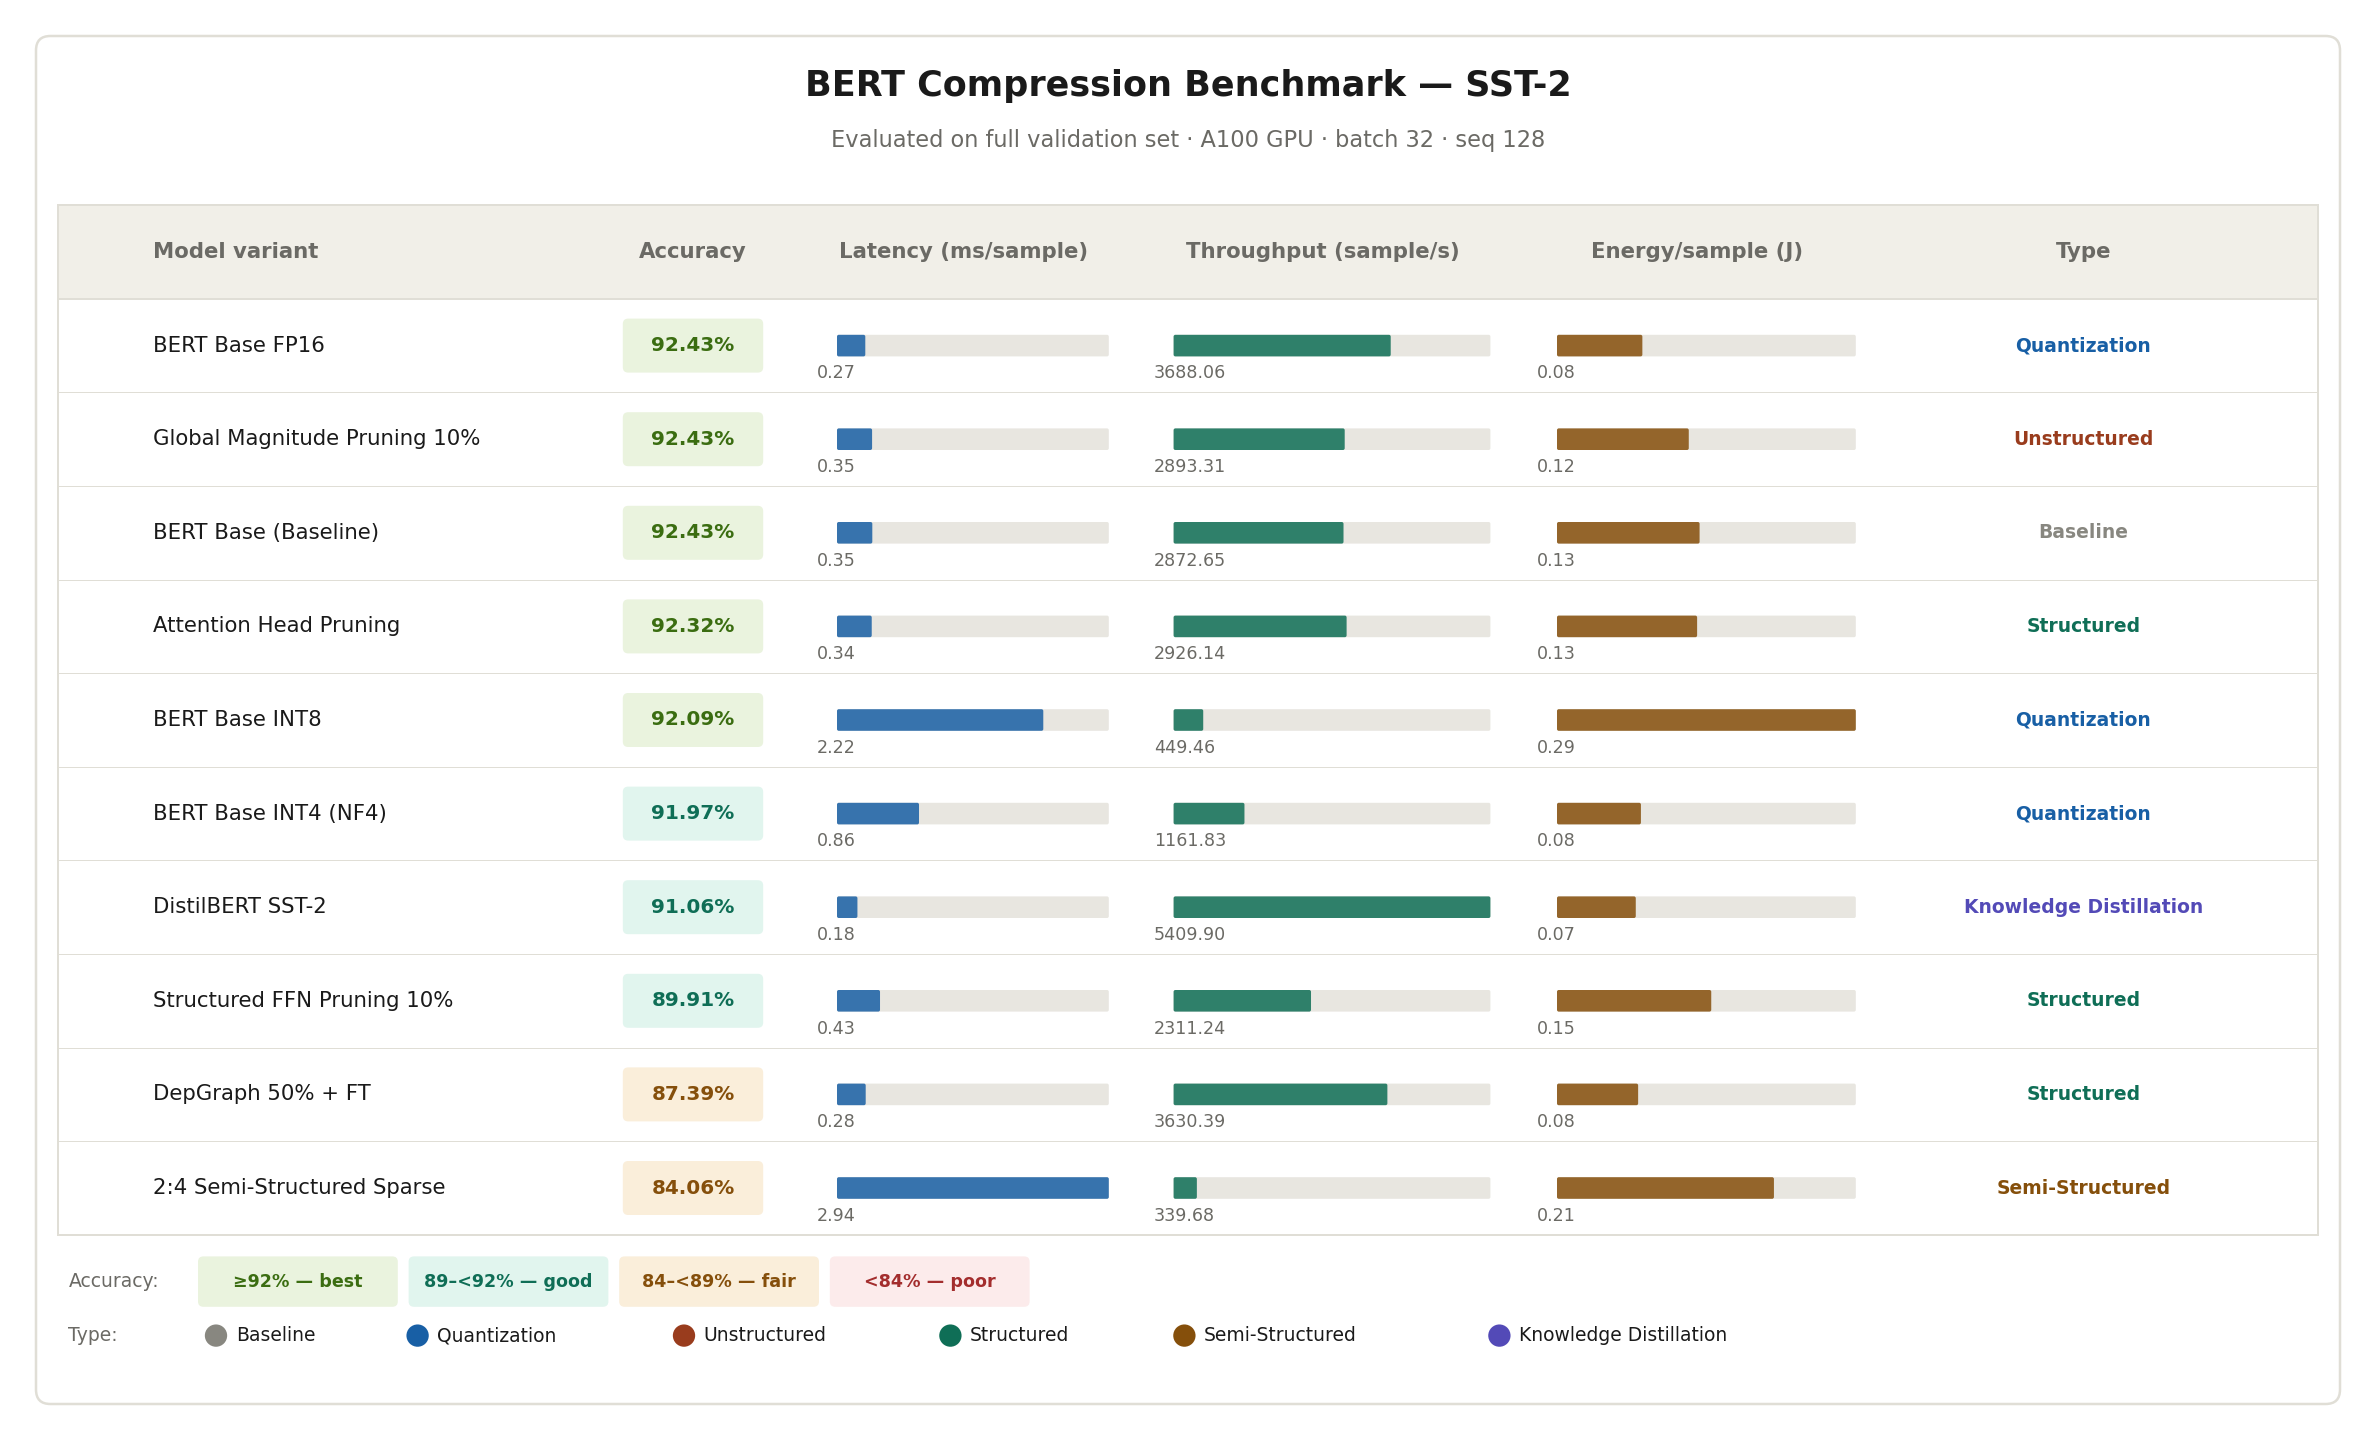

In [ ]:
from IPython.display import Image; display(Image("bert_benchmark_a100gpu.png"))